In [214]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
import pickle
import matplotlib as mpl
import seaborn as sb
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [256]:
import json

path = "info\\non_cnn_analysis.json"
with open(path, 'r') as f:
    results = json.load(f)

path = "info\\cnn_analysis_results.json"
with open(path, 'r') as f:
    cnn_results = json.load(f)

path = "info\\cnn_analysis_results2.json"
with open(path, 'r') as f:
    cnn_results2 = json.load(f)

path = "info\\cnn_analysis_results_orth_rand.json"
with open(path, 'r') as f:
    cnn_results_rand = json.load(f)

path = "info\\mlp_LA_clean_analysis_results.json"
with open(path, 'r') as f:
    mlp_results_LA_clean = json.load(f)

# Part 1: Orth Data

### Compare mlp and linear orth

In [216]:
mlp_orth = results['mlp\\orth']
linear_orth = results['linear\\orth']
cnn_orth = cnn_results['cnn\\orth']
cnn_orth2 = cnn_results2['cnn\\orth new']

First, determine optimal hyperparameters, firstly for the 128-64 model

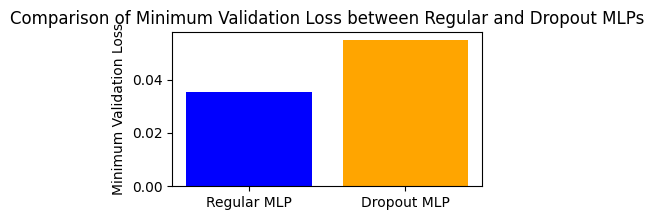

In [205]:
options = ['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1']

model_regular = mlp_orth['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images']
model_dropout = mlp_orth['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1']

regular_min_val_loss = model_regular['min val loss']
dropout_min_val_loss = model_dropout['min val loss']

plt.figure(figsize=(4,2))
plt.bar(['Regular MLP', 'Dropout MLP'], [regular_min_val_loss, dropout_min_val_loss], color=['blue', 'orange'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss between Regular and Dropout MLPs')
plt.show()

Ok lets compare all the main models.

In [206]:
cnn_orth2.keys()

dict_keys(['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-do0.1'])

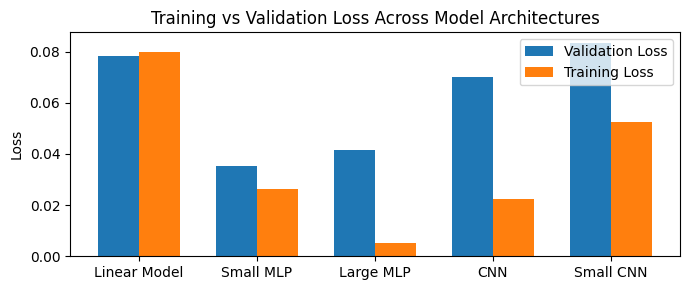

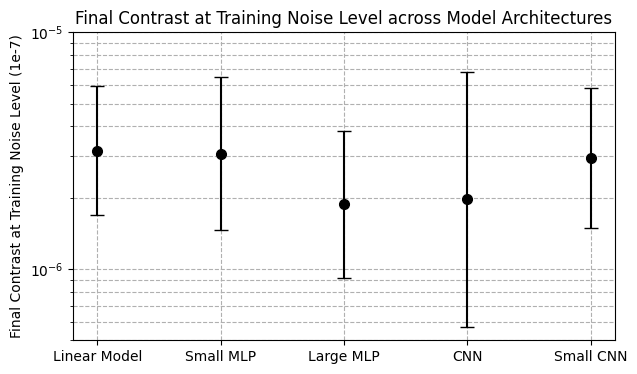

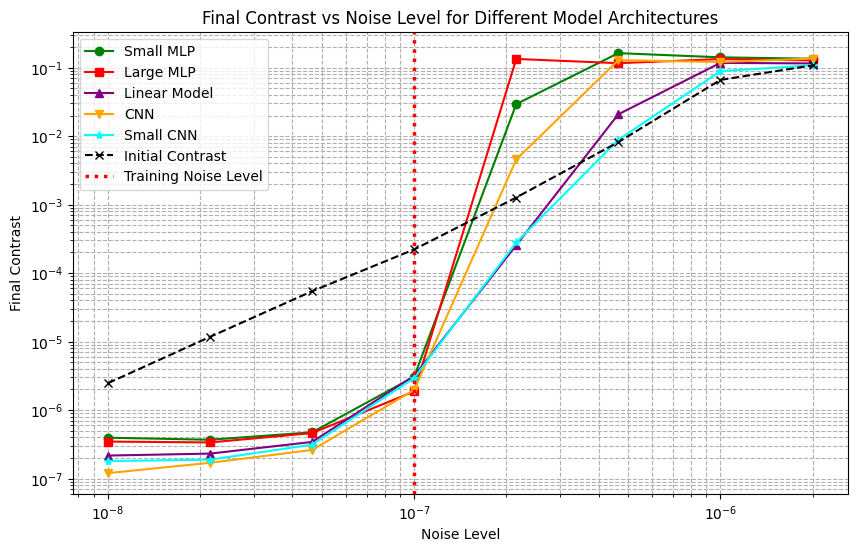

In [217]:
small_mlp_regular = mlp_orth['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images']
large_mlp_regular = mlp_orth['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images']
# cnn_mlp_regular = cnn_orth['exp-fc1-zscore-ep1000-bs2048-lr1e-3-s42-h128-64-images']
cnn_mlp = cnn_orth2['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images']
cnn_mlp_small = cnn_orth2['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small']
linear_regular = linear_orth['exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images']

labels = ['Linear Model', 'Small MLP', 'Large MLP', 'CNN', 'Small CNN']
x = np.arange(len(labels))
width = 0.35

val_losses = [
    linear_regular['min val loss'],
    small_mlp_regular['min val loss'],
    large_mlp_regular['min val loss'],
    cnn_mlp['min val loss'],
    cnn_mlp_small['min val loss']
]

train_losses = [
    linear_regular[' train loss'],
    small_mlp_regular[' train loss'],
    large_mlp_regular[' train loss'],
    cnn_mlp[' train loss'],
    cnn_mlp_small[' train loss']
]

plt.figure(figsize=(7, 3))

plt.bar(x - width/2, val_losses, width, label='Validation Loss')
plt.bar(x + width/2, train_losses, width, label='Training Loss')

plt.xticks(x, labels)
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Across Model Architectures')
plt.legend()
plt.tight_layout()
plt.show()


smr_exp1 = small_mlp_regular['exp1 evaluation stats']
lmr_exp1 = large_mlp_regular['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
# cnnr_exp1 = cnn_mlp_regular['exp1 evaluation stats']
cnns_exp1 = cnn_mlp['exp1 evaluation stats']
cnnt_exp1 = cnn_mlp_small['exp1 evaluation stats']

smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
# cnnr_exp1_final_contrast_log_mean = np.array(cnnr_exp1['final_contrast_log10']['mean'])
cnns_exp1_final_contrast_log_mean = np.array(cnns_exp1['final_contrast_log10']['mean'])
cnnt_exp1_final_contrast_log_mean = np.array(cnnt_exp1['final_contrast_log10']['mean'])

smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
# cnnr_exp1_final_contrast = 10 ** cnnr_exp1_final_contrast_log_mean
cnns_exp1_final_contrast = 10 ** cnns_exp1_final_contrast_log_mean
cnnt_exp1_final_contrast = 10 ** cnnt_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
# cnnr_exp1_final_contrast_log_std = np.array(cnnr_exp1['final_contrast_log10']['std'])
cnns_exp1_final_contrast_log_std = np.array(cnns_exp1['final_contrast_log10']['std'])
cnnt_exp1_final_contrast_log_std = np.array(cnnt_exp1['final_contrast_log10']['std'])

initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']

train_noise_level = 1e-7

noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]

def log_std_to_linear_error(log_mean, log_std):
    base = 10 ** log_mean
    lower_err = base - 10 ** (log_mean - log_std)
    upper_err = 10 ** (log_mean + log_std) - base
    return np.array([lower_err, upper_err])


model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_mean[noise_level_index], smr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_mean[noise_level_index], lmr_exp1_final_contrast_log_std[noise_level_index]),
    # log_std_to_linear_error(cnnr_exp1_final_contrast_log_mean[noise_level_index], cnnr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnns_exp1_final_contrast_log_mean[noise_level_index], cnns_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnnt_exp1_final_contrast_log_mean[noise_level_index], cnnt_exp1_final_contrast_log_std[noise_level_index]),
]

yerr = np.array(model_error_bars).T

yerr = np.array(model_error_bars).T  # shape: (2, num_models) or (num_models,)
yerr_original = yerr.copy()
means = [
    lr_exp1_final_contrast[noise_level_index],
    smr_exp1_final_contrast[noise_level_index],
    lmr_exp1_final_contrast[noise_level_index],
    cnns_exp1_final_contrast[noise_level_index],
    cnnt_exp1_final_contrast[noise_level_index],
]

labels = ['Linear Model', 'Small MLP', 'Large MLP', 'CNN', 'Small CNN']
x = np.arange(len(labels))

plt.figure(figsize=(7, 4))

plt.errorbar(
    x,
    means,
    yerr=yerr,
    fmt='o',
    markersize=7,
    capsize=5,
    linestyle='none',
    color='black'
)

plt.xticks(x, labels)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 1e-5)
plt.grid(True, which="both", ls="--")

plt.show()


plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
# plt.plot(noise_levels, cnnr_exp1_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, cnns_exp1_final_contrast, marker='v', label='CNN', color='orange')
plt.plot(noise_levels, cnnt_exp1_final_contrast, marker='*', label='Small CNN', color='cyan')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
# plt.xlim(1e-8, 1.1e-7)
# plt.ylim(5e-8, 1e-5)
# plt.xlim(0.9e-7, 2.1e-6)
# plt.ylim(1e-7, 1)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

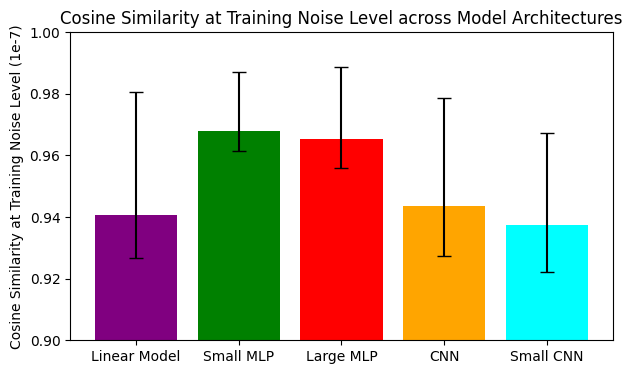

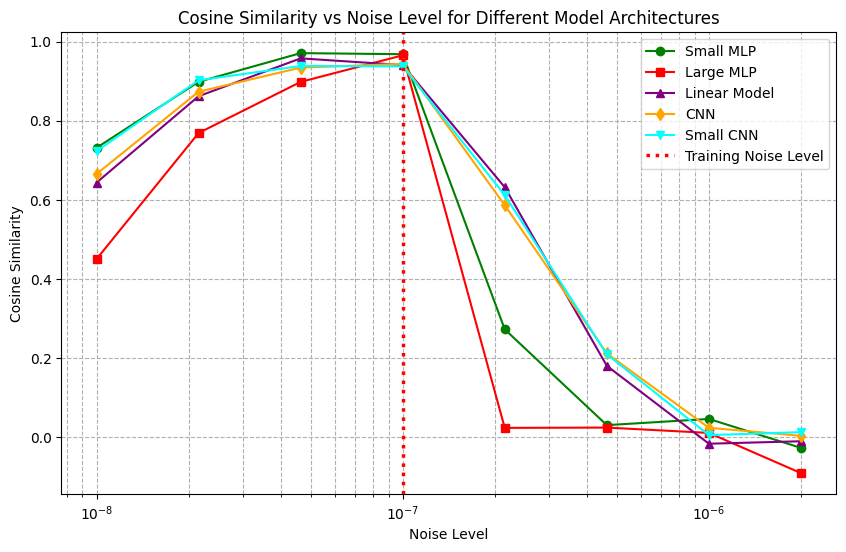

In [208]:
smr_exp1 = small_mlp_regular['exp1 evaluation stats']
lmr_exp1 = large_mlp_regular['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnn_exp1 = cnn_mlp['exp1 evaluation stats']
cnns_exp1 = cnn_mlp_small['exp1 evaluation stats']

smr_exp1_cos_sim = np.array(smr_exp1['cosine_similarity']['mean'])
lmr_exp1_cos_sim = np.array(lmr_exp1['cosine_similarity']['mean'])
lr_exp1_cos_sim = np.array(lr_exp1['cosine_similarity']['mean'])
cnn_exp1_cos_sim = np.array(cnn_exp1['cosine_similarity']['mean'])
cnns_exp1_cos_sim = np.array(cnns_exp1['cosine_similarity']['mean'])

smr_exp1_cos_sim_p25 = np.array(smr_exp1['cosine_similarity']['p25'])[noise_level_index]
lmr_exp1_cos_sim_p25 = np.array(lmr_exp1['cosine_similarity']['p25'])[noise_level_index]
lr_exp1_cos_sim_p25 = np.array(lr_exp1['cosine_similarity']['p25'])[noise_level_index]
cnn_exp1_cos_sim_p25 = np.array(cnn_exp1['cosine_similarity']['p25'])[noise_level_index]
cnns_exp1_cos_sim_p25 = np.array(cnns_exp1['cosine_similarity']['p25'])[noise_level_index]

smr_exp1_cos_sim_p75 = np.array(smr_exp1['cosine_similarity']['p75'])[noise_level_index]
lmr_exp1_cos_sim_p75 = np.array(lmr_exp1['cosine_similarity']['p75'])[noise_level_index]
lr_exp1_cos_sim_p75 = np.array(lr_exp1['cosine_similarity']['p75'])[noise_level_index]
cnn_exp1_cos_sim_p75 = np.array(cnn_exp1['cosine_similarity']['p75'])[noise_level_index]
cnns_exp1_cos_sim_p75 = np.array(cnns_exp1['cosine_similarity']['p75'])[noise_level_index]
yerr = np.array([
    [lr_exp1_cos_sim[noise_level_index] - lr_exp1_cos_sim_p25, lr_exp1_cos_sim_p75 - lr_exp1_cos_sim[noise_level_index]],
    [smr_exp1_cos_sim[noise_level_index] - smr_exp1_cos_sim_p25, smr_exp1_cos_sim_p75 - smr_exp1_cos_sim[noise_level_index]],
    [lmr_exp1_cos_sim[noise_level_index] - lmr_exp1_cos_sim_p25, lmr_exp1_cos_sim_p75 - lmr_exp1_cos_sim[noise_level_index]],
    [cnn_exp1_cos_sim[noise_level_index] - cnn_exp1_cos_sim_p25, cnn_exp1_cos_sim_p75 - cnn_exp1_cos_sim[noise_level_index]],
    [cnns_exp1_cos_sim[noise_level_index] - cnns_exp1_cos_sim_p25, cnns_exp1_cos_sim_p75 - cnns_exp1_cos_sim[noise_level_index]]
])

yerr = yerr.T

plt.figure(figsize=(7,4))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', "CNN", "Small CNN"],
        [lr_exp1_cos_sim[noise_level_index], smr_exp1_cos_sim[noise_level_index], lmr_exp1_cos_sim[noise_level_index], cnn_exp1_cos_sim[noise_level_index], cnns_exp1_cos_sim[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'orange', 'cyan'], capsize=5)
plt.ylabel('Cosine Similarity at Training Noise Level (1e-7)')
plt.title('Cosine Similarity at Training Noise Level across Model Architectures')
plt.ylim(0.90, 1.0)
plt.show()


plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_cos_sim, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_cos_sim, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnn_exp1_cos_sim, marker='d', label='CNN', color='orange')
plt.plot(noise_levels, cnns_exp1_cos_sim, marker='v', label='Small CNN', color='cyan')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for Different Model Architectures')
# plt.xlim(0.9e-8, 1.1e-7)
# plt.ylim(0.3, 1)
# plt.xlim(0.9e-7, 2.1e-6)
# plt.ylim(-0.1, 1)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

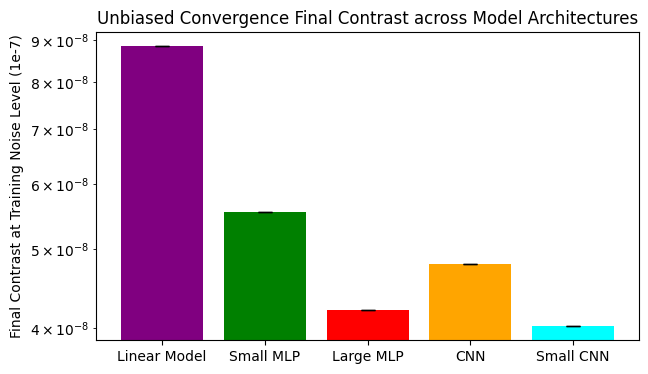

In [209]:
smr_conv = small_mlp_regular['convergence_stats']
lmr_conv = large_mlp_regular['convergence_stats']
cnn_conv = cnn_mlp['convergence_stats']
cnns_conv = cnn_mlp_small['convergence_stats']
lr_conv = linear_regular['convergence_stats']


smr_final_contrast_log10_mean = np.array(smr_conv['final_contrast_log10']['mean'])
lmr_final_contrast_log10_mean = np.array(lmr_conv['final_contrast_log10']['mean'])
cnn_final_contrast_log10_mean = np.array(cnn_conv['final_contrast_log10']['mean'])
cnns_final_contrast_log10_mean = np.array(cnns_conv['final_contrast_log10']['mean'])
lr_final_contrast_log10_mean = np.array(lr_conv['final_contrast_log10']['mean'])

smr_final_contrast = 10 ** smr_final_contrast_log10_mean
lmr_final_contrast = 10 ** lmr_final_contrast_log10_mean
cnn_final_contrast = 10 ** cnn_final_contrast_log10_mean
cnns_final_contrast = 10 ** cnns_final_contrast_log10_mean
lr_final_contrast = 10 ** lr_final_contrast_log10_mean

smr_final_contrast_log10_std = np.array(smr_conv['final_contrast_log10']['std'])
lmr_final_contrast_log10_std = np.array(lmr_conv['final_contrast_log10']['std'])
cnn_final_contrast_log10_std = np.array(cnn_conv['final_contrast_log10']['std'])
cnns_final_contrast_log10_std = np.array(cnns_conv['final_contrast_log10']['std'])
lr_final_contrast_log10_std = np.array(lr_conv['final_contrast_log10']['std'])

yerr = np.array([
    log_std_to_linear_error(lr_final_contrast_log10_mean[0], lr_final_contrast_log10_std[0]),
    log_std_to_linear_error(smr_final_contrast_log10_mean[0], smr_final_contrast_log10_std[0]),
    log_std_to_linear_error(lmr_final_contrast_log10_mean[0], lmr_final_contrast_log10_std[0]),
    log_std_to_linear_error(cnn_final_contrast_log10_mean[0], cnn_final_contrast_log10_std[0]),
    log_std_to_linear_error(cnns_final_contrast_log10_mean[0], cnns_final_contrast_log10_std[0]),]).T

plt.figure(figsize=(7,4))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', "CNN", "Small CNN"],
        [lr_final_contrast[0], smr_final_contrast[0], lmr_final_contrast[0], cnn_final_contrast[0], cnns_final_contrast[0]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'orange', 'cyan'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Unbiased Convergence Final Contrast across Model Architectures')
plt.yscale('log')
# plt.ylim(5e-7, 1e-5)
plt.show()

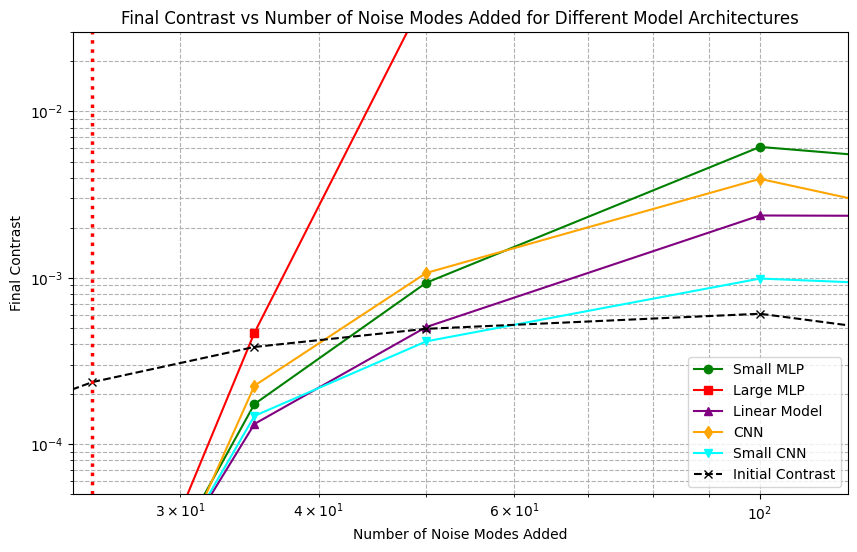

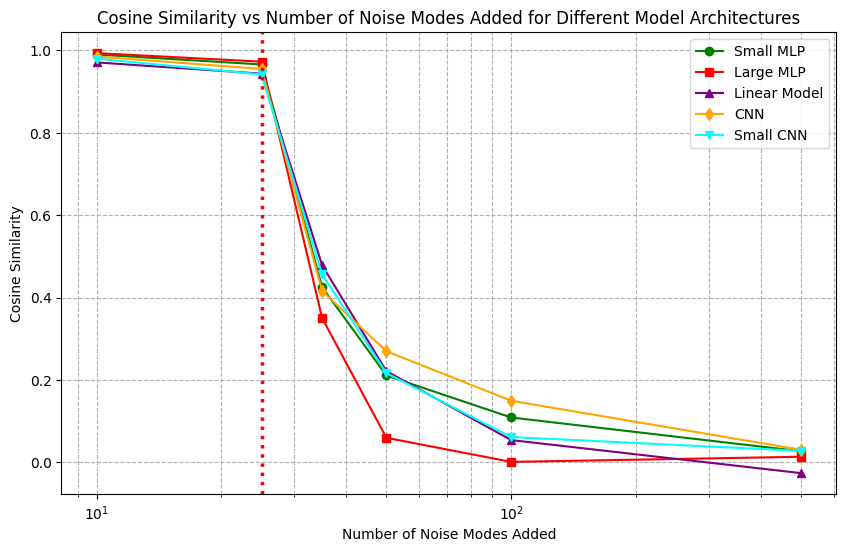

In [210]:
smr_exp2 = small_mlp_regular['exp2 evaluation stats']
lmr_exp2 = large_mlp_regular['exp2 evaluation stats']
lr_exp2 = linear_regular['exp2 evaluation stats']
cnn_exp2 = cnn_mlp['exp2 evaluation stats']
cnns_exp2 = cnn_mlp_small['exp2 evaluation stats']
# cnnr_exp2 = cnn_mlp_regular['exp2 evaluation stats'] --- IGNORE ---

noise_mode_amounts = smr_exp2['noise_mode_amounts']

smr_exp2_final_contrast_log_mean = np.array(smr_exp2['final_contrast_log10']['mean'])
lmr_exp2_final_contrast_log_mean = np.array(lmr_exp2['final_contrast_log10']['mean'])
lr_exp2_final_contrast_log_mean = np.array(lr_exp2['final_contrast_log10']['mean'])
cnn_exp2_final_contrast_log_mean = np.array(cnn_exp2['final_contrast_log10']['mean'])
cnns_exp2_final_contrast_log_mean = np.array(cnns_exp2['final_contrast_log10']['mean'])

smr_exp2_final_contrast = 10 ** smr_exp2_final_contrast_log_mean
lmr_exp2_final_contrast = 10 ** lmr_exp2_final_contrast_log_mean
lr_exp2_final_contrast = 10 ** lr_exp2_final_contrast_log_mean 
cnn_exp2_final_contrast = 10 ** cnn_exp2_final_contrast_log_mean
cnns_exp2_final_contrast = 10 ** cnns_exp2_final_contrast_log_mean
smr_exp2_cos_sim = np.array(smr_exp2['cosine_similarity']['mean'])
lmr_exp2_cos_sim = np.array(lmr_exp2['cosine_similarity']['mean'])
lr_exp2_cos_sim = np.array(lr_exp2['cosine_similarity']['mean'])
cnn_exp2_cos_sim = np.array(cnn_exp2['cosine_similarity']['mean'])
cnns_exp2_cos_sim = np.array(cnns_exp2['cosine_similarity']['mean'])

initial_contrast = 10 ** np.array(smr_exp2['initial_contrast_log10']['mean'])

plt.figure(figsize=(10,6))
plt.plot(noise_mode_amounts, smr_exp2_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_mode_amounts, lmr_exp2_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_mode_amounts, lr_exp2_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_mode_amounts, cnn_exp2_final_contrast, marker='d', label='CNN', color='orange')
plt.plot(noise_mode_amounts, cnns_exp2_final_contrast, marker='v', label='Small CNN', color='cyan')
plt.plot(noise_mode_amounts, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Number of Noise Modes Added')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Number of Noise Modes Added for Different Model Architectures')
plt.legend()
plt.axvline(x=25, color='red', linestyle=':', label='Training Noise Modes', linewidth=2.5)
plt.grid(True, which="both", ls="--")
plt.xlim(24, 120)
plt.ylim(5e-5, 3e-2)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_mode_amounts, smr_exp2_cos_sim, marker='o', label='Small MLP', color='green')
plt.plot(noise_mode_amounts, lmr_exp2_cos_sim, marker='s', label='Large MLP', color='red')
plt.plot(noise_mode_amounts, lr_exp2_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_mode_amounts, cnn_exp2_cos_sim, marker='d', label='CNN', color='orange')
plt.plot(noise_mode_amounts, cnns_exp2_cos_sim, marker='v', label='Small CNN', color='cyan')
plt.xscale('log')
plt.xlabel('Number of Noise Modes Added')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Number of Noise Modes Added for Different Model Architectures')
plt.legend()
plt.axvline(x=25, color='red', linestyle=':', label='Training Noise Modes', linewidth=2.5)
plt.grid(True, which="both", ls="--")
plt.show()


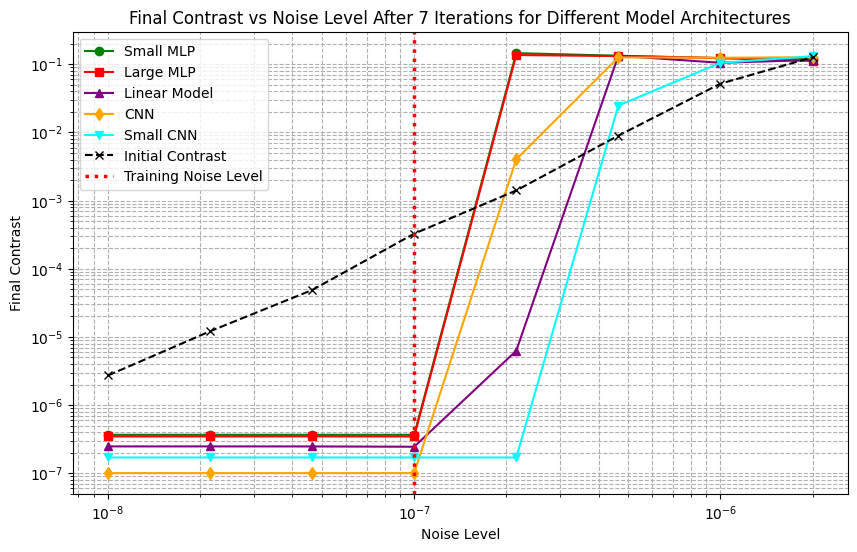

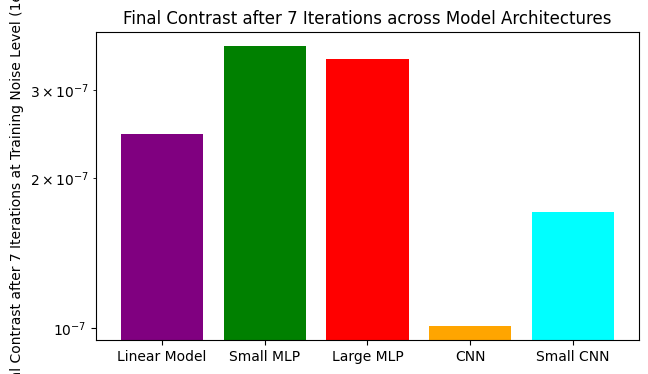

In [211]:
smr_exp3 = small_mlp_regular['exp3 evaluation stats']
lmr_exp3 = large_mlp_regular['exp3 evaluation stats']
lr_exp3 = linear_regular['exp3 evaluation stats']
cnn_exp3 = cnn_mlp['exp3 evaluation stats']
cnns_exp3 = cnn_mlp_small['exp3 evaluation stats']
# cnnr_exp3 = cnn_mlp_regular['exp3 evaluation stats'] --- IGNORE

noise_levels_exp3 = smr_exp3['noise_levels']
smr_exp3_final_contrast_log_mean = np.array(smr_exp3['final_contrast_log10']['mean'])
lmr_exp3_final_contrast_log_mean = np.array(lmr_exp3['final_contrast_log10']['mean'])
lr_exp3_final_contrast_log_mean = np.array(lr_exp3['final_contrast_log10']['mean'])
cnn_exp3_final_contrast_log_mean = np.array(cnn_exp3['final_contrast_log10']['mean'])
cnns_exp3_final_contrast_log_mean = np.array(cnns_exp3['final_contrast_log10']['mean'])
smr_exp3_final_contrast = 10 ** smr_exp3_final_contrast_log_mean
lmr_exp3_final_contrast = 10 ** lmr_exp3_final_contrast_log_mean
lr_exp3_final_contrast = 10 ** lr_exp3_final_contrast_log_mean
cnn_exp3_final_contrast = 10 ** cnn_exp3_final_contrast_log_mean
cnns_exp3_final_contrast = 10 ** cnns_exp3_final_contrast_log_mean
initial_contrast = 10 ** np.array(smr_exp3['initial_contrast_log10']['mean'])
    
plt.figure(figsize=(10,6))
plt.plot(noise_levels_exp3, smr_exp3_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels_exp3, lmr_exp3_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels_exp3, lr_exp3_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels_exp3, cnn_exp3_final_contrast, marker='d', label='CNN', color='orange')
plt.plot(noise_levels_exp3, cnns_exp3_final_contrast, marker='v', label='Small CNN', color='cyan')
plt.plot(noise_levels_exp3, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level After 7 Iterations for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

smr_conv_final_contrast = smr_exp3_final_contrast[noise_level_index]
lmr_conv_final_contrast = lmr_exp3_final_contrast[noise_level_index]
lr_conv_final_contrast = lr_exp3_final_contrast[noise_level_index]
cnn_conv_final_contrast = cnn_exp3_final_contrast[noise_level_index]
cnns_conv_final_contrast = cnns_exp3_final_contrast[noise_level_index]
plt.figure(figsize=(7,4))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', "CNN", "Small CNN"],
        [lr_conv_final_contrast, smr_conv_final_contrast, lmr_conv_final_contrast, cnn_conv_final_contrast, cnns_conv_final_contrast],
        color=['purple', 'green', 'red', 'orange', 'cyan'])
plt.ylabel('Final Contrast after 7 Iterations at Training Noise Level (1e-7)')
plt.title('Final Contrast after 7 Iterations across Model Architectures')
plt.yscale('log')
# plt.ylim(5e-7, 1e-5)
plt.show()



### Now, let's add the random model training for MLPs

In [83]:
mlp_orth_rand = results['mlp\\orth rand']
mlp_orth_rand.keys()

dict_keys(['exp-fc1-log-ep1500-bs256-lr1e-3-s42-h256-128-64-images', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h256-128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h256-128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.1'])

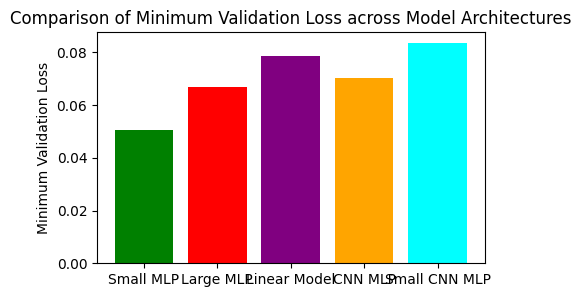

In [88]:
small_mlp_rand = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images']
large_mlp_rand = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images']

plt.figure(figsize=(5,3))
plt.bar(['Small MLP', 'Large MLP', 'Linear Model', "CNN MLP", "Small CNN MLP"],
        [small_mlp_rand['min val loss'], large_mlp_rand['min val loss'], linear_regular['min val loss'], cnn_mlp['min val loss'], cnn_mlp_small['min val loss']],
        color=['green', 'red', 'purple', 'orange', 'cyan'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss across Model Architectures')
plt.show()


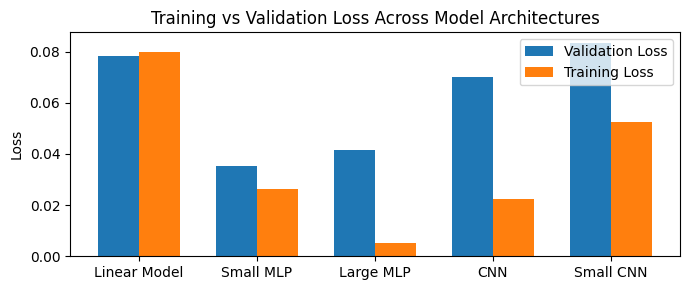

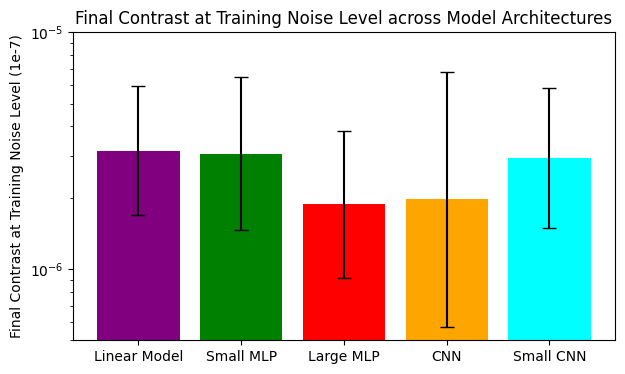

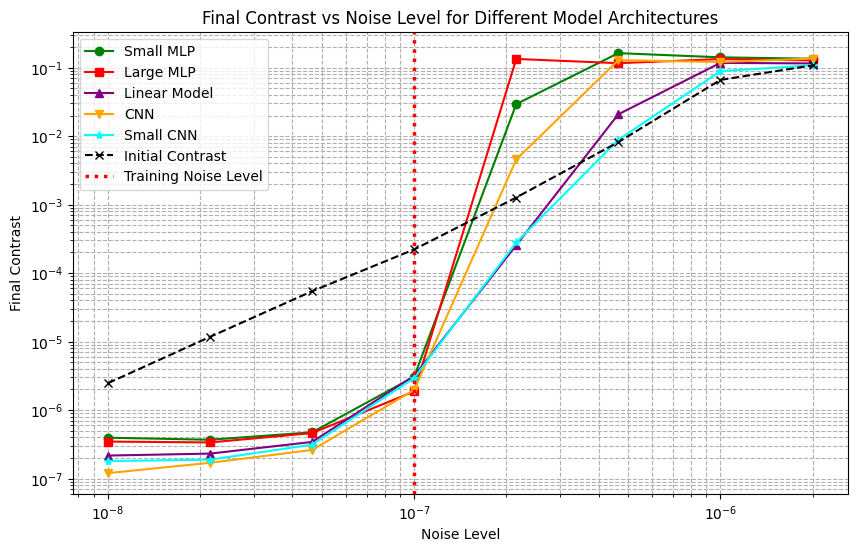

In [219]:
# small_mlp_regular = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images']
# large_mlp_regular = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images']
# cnn_mlp_regular = cnn_orth['exp-fc1-zscore-ep1000-bs2048-lr1e-3-s42-h128-64-images']
cnn_mlp = cnn_orth2['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images']
cnn_mlp_small = cnn_orth2['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small']
linear_regular = linear_orth['exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images']

labels = ['Linear Model', 'Small MLP', 'Large MLP', 'CNN', 'Small CNN']
x = np.arange(len(labels))
width = 0.35

val_losses = [
    linear_regular['min val loss'],
    small_mlp_regular['min val loss'],
    large_mlp_regular['min val loss'],
    cnn_mlp['min val loss'],
    cnn_mlp_small['min val loss']
]

train_losses = [
    linear_regular[' train loss'],
    small_mlp_regular[' train loss'],
    large_mlp_regular[' train loss'],
    cnn_mlp[' train loss'],
    cnn_mlp_small[' train loss']
]

plt.figure(figsize=(7, 3))

plt.bar(x - width/2, val_losses, width, label='Validation Loss')
plt.bar(x + width/2, train_losses, width, label='Training Loss')

plt.xticks(x, labels)
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Across Model Architectures')
plt.legend()
plt.tight_layout()
plt.show()


smr_exp1 = small_mlp_regular['exp1 evaluation stats']
lmr_exp1 = large_mlp_regular['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
# cnnr_exp1 = cnn_mlp_regular['exp1 evaluation stats']
cnns_exp1 = cnn_mlp['exp1 evaluation stats']
cnnt_exp1 = cnn_mlp_small['exp1 evaluation stats']

smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
# cnnr_exp1_final_contrast_log_mean = np.array(cnnr_exp1['final_contrast_log10']['mean'])
cnns_exp1_final_contrast_log_mean = np.array(cnns_exp1['final_contrast_log10']['mean'])
cnnt_exp1_final_contrast_log_mean = np.array(cnnt_exp1['final_contrast_log10']['mean'])

smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
# cnnr_exp1_final_contrast = 10 ** cnnr_exp1_final_contrast_log_mean
cnns_exp1_final_contrast = 10 ** cnns_exp1_final_contrast_log_mean
cnnt_exp1_final_contrast = 10 ** cnnt_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
# cnnr_exp1_final_contrast_log_std = np.array(cnnr_exp1['final_contrast_log10']['std'])
cnns_exp1_final_contrast_log_std = np.array(cnns_exp1['final_contrast_log10']['std'])
cnnt_exp1_final_contrast_log_std = np.array(cnnt_exp1['final_contrast_log10']['std'])

initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']

train_noise_level = 1e-7

noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]

def log_std_to_linear_error(log_mean, log_std):
    base = 10 ** log_mean
    lower_err = base - 10 ** (log_mean - log_std)
    upper_err = 10 ** (log_mean + log_std) - base
    return np.array([lower_err, upper_err])


model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_mean[noise_level_index], smr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_mean[noise_level_index], lmr_exp1_final_contrast_log_std[noise_level_index]),
    # log_std_to_linear_error(cnnr_exp1_final_contrast_log_mean[noise_level_index], cnnr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnns_exp1_final_contrast_log_mean[noise_level_index], cnns_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnnt_exp1_final_contrast_log_mean[noise_level_index], cnnt_exp1_final_contrast_log_std[noise_level_index]),
]

yerr = np.array(model_error_bars).T

plt.figure(figsize=(7,4))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', "CNN", "Small CNN"],
        [lr_exp1_final_contrast[noise_level_index], smr_exp1_final_contrast[noise_level_index], lmr_exp1_final_contrast[noise_level_index], cnns_exp1_final_contrast[noise_level_index], cnnt_exp1_final_contrast[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'orange', 'cyan'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 1e-5)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
# plt.plot(noise_levels, cnnr_exp1_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, cnns_exp1_final_contrast, marker='v', label='CNN', color='orange')
plt.plot(noise_levels, cnnt_exp1_final_contrast, marker='*', label='Small CNN', color='cyan')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
# plt.xlim(1e-8, 1.1e-7)
# plt.ylim(5e-8, 1e-5)
# plt.xlim(0.9e-7, 2.1e-6)
# plt.ylim(1e-7, 1)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

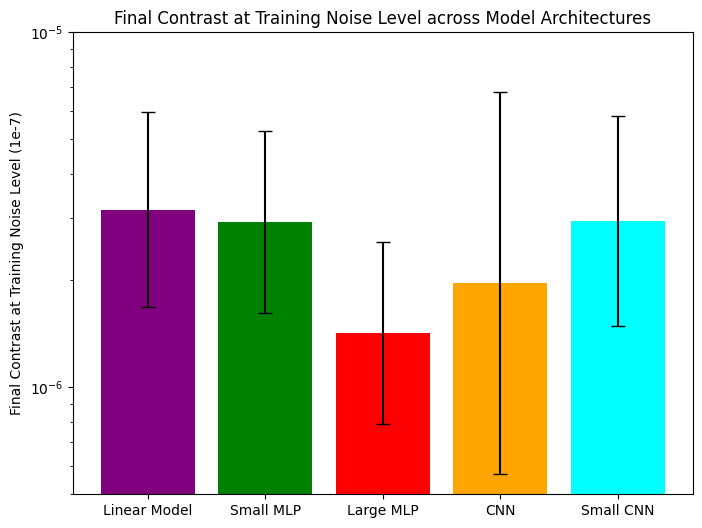

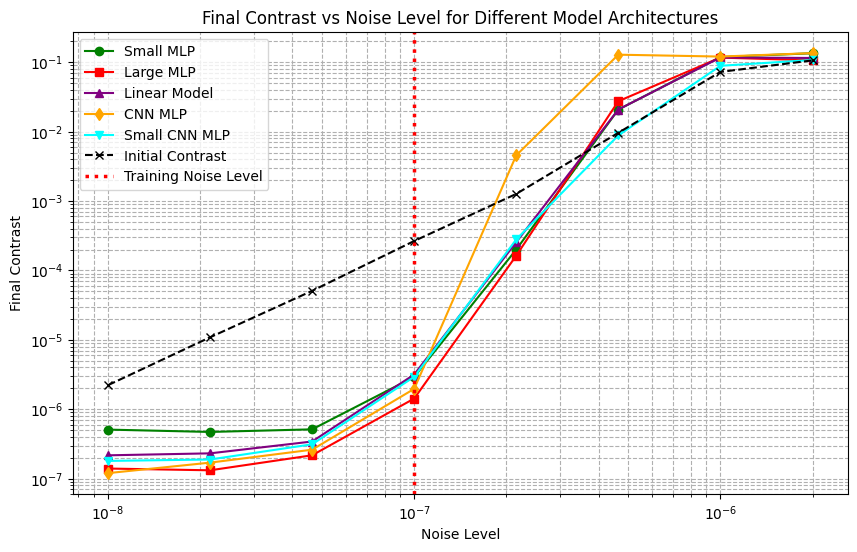

In [213]:
smr_exp1 = small_mlp_rand['exp1 evaluation stats']
lmr_exp1 = large_mlp_rand['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnn_exp1 = cnn_mlp['exp1 evaluation stats']
cnns_exp1 = cnn_mlp_small['exp1 evaluation stats']

smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
cnn_exp1_final_contrast_log_mean = np.array(cnn_exp1['final_contrast_log10']['mean'])
cnns_exp1_final_contrast_log_mean = np.array(cnns_exp1['final_contrast_log10']['mean'])

smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
cnn_exp1_final_contrast = 10 ** cnn_exp1_final_contrast_log_mean
cnns_exp1_final_contrast = 10 ** cnns_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
cnn_exp1_final_contrast_log_std = np.array(cnn_exp1['final_contrast_log10']['std'])
cnns_exp1_final_contrast_log_std = np.array(cnns_exp1['final_contrast_log10']['std'])

initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']

train_noise_level = 1e-7

noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]


def log_std_to_linear_error(log_mean, log_std):
    base = 10 ** log_mean
    lower_err = base - 10 ** (log_mean - log_std)
    upper_err = 10 ** (log_mean + log_std) - base
    return np.array([lower_err, upper_err])


model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_mean[noise_level_index], smr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_mean[noise_level_index], lmr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnn_exp1_final_contrast_log_mean[noise_level_index], cnn_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnns_exp1_final_contrast_log_mean[noise_level_index], cnns_exp1_final_contrast_log_std[noise_level_index])
]

yerr = np.array(model_error_bars).T

plt.figure(figsize=(8,6))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', 'CNN', "Small CNN"],
        [lr_exp1_final_contrast[noise_level_index], smr_exp1_final_contrast[noise_level_index], lmr_exp1_final_contrast[noise_level_index], cnn_exp1_final_contrast[noise_level_index], cnns_exp1_final_contrast[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'orange', 'cyan'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 1e-5)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnn_exp1_final_contrast, marker='d', label='CNN MLP', color='orange')
plt.plot(noise_levels, cnns_exp1_final_contrast, marker='v', label='Small CNN MLP', color='cyan')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
# plt.xlim(1e-8, 1.1e-7)
# plt.ylim(5e-8, 1e-5)

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

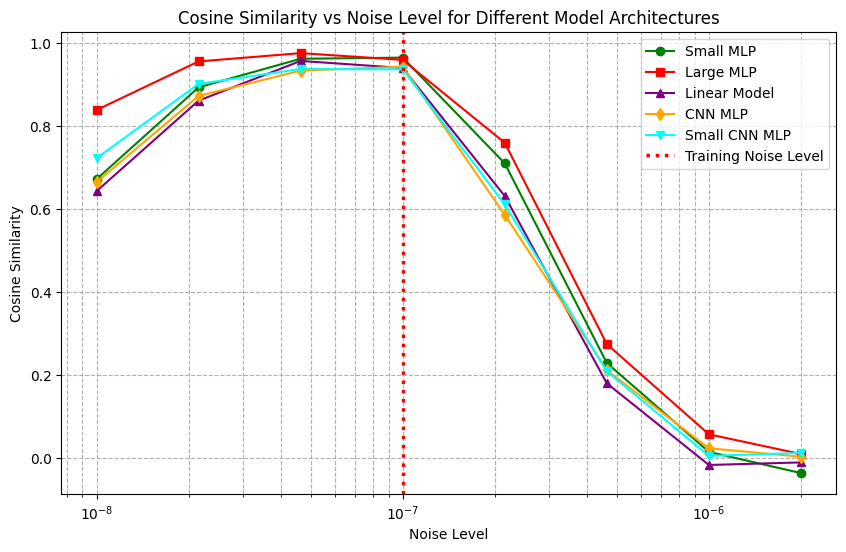

In [90]:
smr_exp1_cos_sim = np.array(smr_exp1['cosine_similarity']['mean'])
lmr_exp1_cos_sim = np.array(lmr_exp1['cosine_similarity']['mean'])
lr_exp1_cos_sim = np.array(lr_exp1['cosine_similarity']['mean'])
cnn_exp1_cos_sim = np.array(cnn_exp1['cosine_similarity']['mean'])
cnns_exp1_cos_sim = np.array(cnns_exp1['cosine_similarity']['mean'])

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_cos_sim, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_cos_sim, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnn_exp1_cos_sim, marker='d', label='CNN MLP', color='orange')
plt.plot(noise_levels, cnns_exp1_cos_sim, marker='v', label='Small CNN MLP', color='cyan')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for Different Model Architectures')
# plt.xlim(1e-8, 1.1e-7)
# plt.ylim(0, 1)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

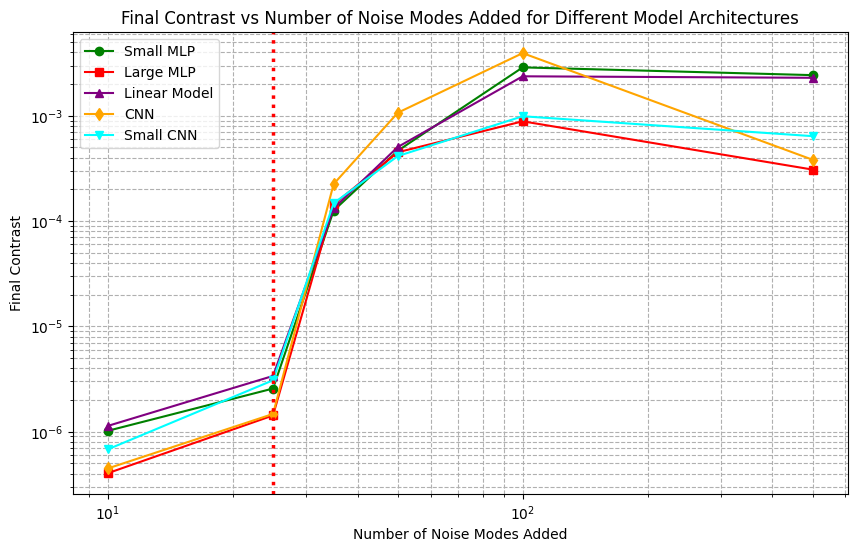

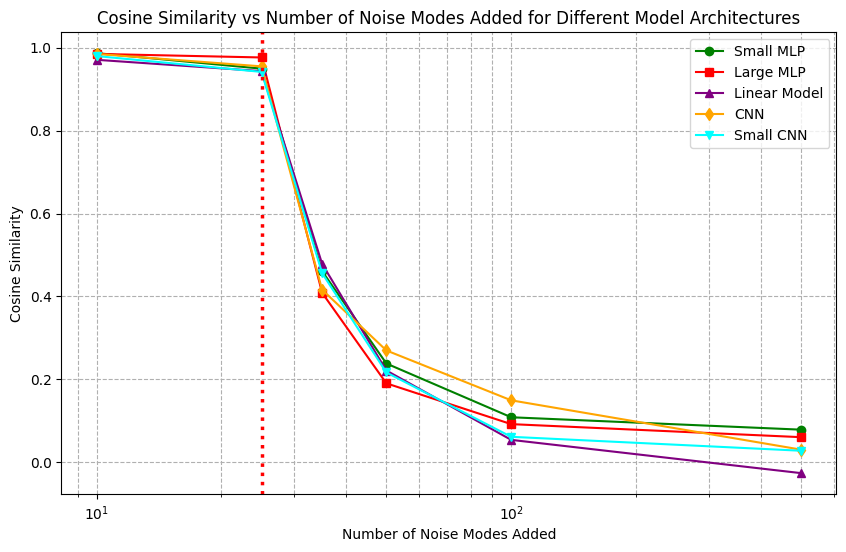

In [92]:
smr_exp2 = small_mlp_rand['exp2 evaluation stats']
lmr_exp2 = large_mlp_rand['exp2 evaluation stats']
lr_exp2 = linear_regular['exp2 evaluation stats']
cnn_exp2 = cnn_mlp['exp2 evaluation stats']
cnns_exp2 = cnn_mlp_small['exp2 evaluation stats']

noise_mode_amounts = smr_exp2['noise_mode_amounts']

smr_exp2_final_contrast_log_mean = np.array(smr_exp2['final_contrast_log10']['mean'])
lmr_exp2_final_contrast_log_mean = np.array(lmr_exp2['final_contrast_log10']['mean'])
lr_exp2_final_contrast_log_mean = np.array(lr_exp2['final_contrast_log10']['mean'])
cnn_exp2_final_contrast_log_mean = np.array(cnn_exp2['final_contrast_log10']['mean'])
cnns_exp2_final_contrast_log_mean = np.array(cnns_exp2['final_contrast_log10']['mean'])

smr_exp2_final_contrast = 10 ** smr_exp2_final_contrast_log_mean
lmr_exp2_final_contrast = 10 ** lmr_exp2_final_contrast_log_mean
lr_exp2_final_contrast = 10 ** lr_exp2_final_contrast_log_mean 
cnn_exp2_final_contrast = 10 ** cnn_exp2_final_contrast_log_mean
cnns_exp2_final_contrast = 10 ** cnns_exp2_final_contrast_log_mean

smr_exp2_cos_sim = np.array(smr_exp2['cosine_similarity']['mean'])
lmr_exp2_cos_sim = np.array(lmr_exp2['cosine_similarity']['mean'])
lr_exp2_cos_sim = np.array(lr_exp2['cosine_similarity']['mean'])
cnn_exp2_cos_sim = np.array(cnn_exp2['cosine_similarity']['mean'])
cnns_exp2_cos_sim = np.array(cnns_exp2['cosine_similarity']['mean'])

plt.figure(figsize=(10,6))
plt.plot(noise_mode_amounts, smr_exp2_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_mode_amounts, lmr_exp2_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_mode_amounts, lr_exp2_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_mode_amounts, cnn_exp2_final_contrast, marker='d', label='CNN', color='orange')
plt.plot(noise_mode_amounts, cnns_exp2_final_contrast, marker='v', label='Small CNN', color='cyan')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Number of Noise Modes Added')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Number of Noise Modes Added for Different Model Architectures')
plt.legend()
plt.axvline(x=25, color='red', linestyle=':', label='Training Noise Modes', linewidth=2.5)
plt.grid(True, which="both", ls="--")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_mode_amounts, smr_exp2_cos_sim, marker='o', label='Small MLP', color='green')
plt.plot(noise_mode_amounts, lmr_exp2_cos_sim, marker='s', label='Large MLP', color='red')
plt.plot(noise_mode_amounts, lr_exp2_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_mode_amounts, cnn_exp2_cos_sim, marker='d', label='CNN', color='orange')
plt.plot(noise_mode_amounts, cnns_exp2_cos_sim, marker='v', label='Small CNN', color='cyan')
plt.xscale('log')
plt.xlabel('Number of Noise Modes Added')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Number of Noise Modes Added for Different Model Architectures')
plt.legend()
plt.axvline(x=25, color='red', linestyle=':', label='Training Noise Modes', linewidth=2.5)
plt.grid(True, which="both", ls="--")
plt.show()


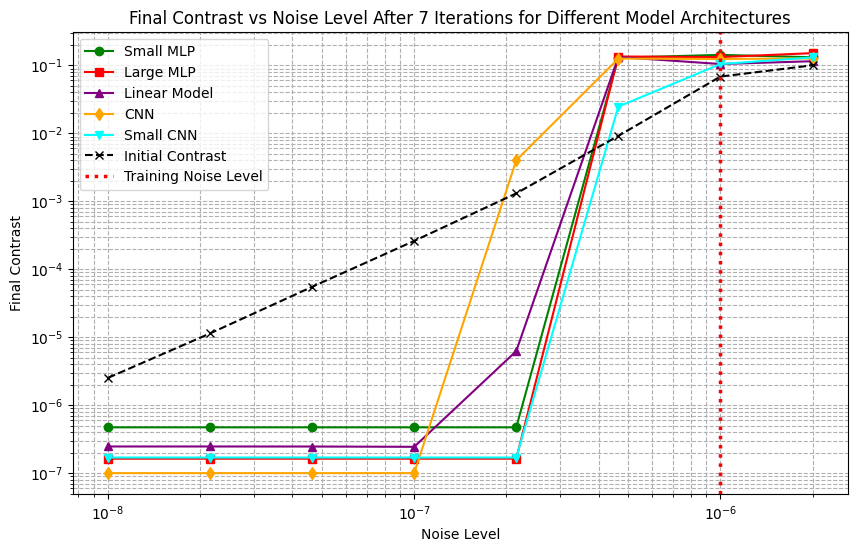

In [201]:
smr_exp3 = small_mlp_rand['exp3 evaluation stats']
lmr_exp3 = large_mlp_rand['exp3 evaluation stats']
lr_exp3 = linear_regular['exp3 evaluation stats']
cnn_exp3 = cnn_mlp['exp3 evaluation stats']
cnns_exp3 = cnn_mlp_small['exp3 evaluation stats']

noise_levels_exp3 = smr_exp3['noise_levels']
smr_exp3_final_contrast_log_mean = np.array(smr_exp3['final_contrast_log10']['mean'])
lmr_exp3_final_contrast_log_mean = np.array(lmr_exp3['final_contrast_log10']['mean'])
lr_exp3_final_contrast_log_mean = np.array(lr_exp3['final_contrast_log10']['mean'])
cnn_exp3_final_contrast_log_mean = np.array(cnn_exp3['final_contrast_log10']['mean'])
cnns_exp3_final_contrast_log_mean = np.array(cnns_exp3['final_contrast_log10']['mean'])

smr_exp3_final_contrast = 10 ** smr_exp3_final_contrast_log_mean
lmr_exp3_final_contrast = 10 ** lmr_exp3_final_contrast_log_mean
lr_exp3_final_contrast = 10 ** lr_exp3_final_contrast_log_mean
cnn_exp3_final_contrast = 10 ** cnn_exp3_final_contrast_log_mean
cnns_exp3_final_contrast = 10 ** cnns_exp3_final_contrast_log_mean
plt.figure(figsize=(10,6))
plt.plot(noise_levels_exp3, smr_exp3_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels_exp3, lmr_exp3_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels_exp3, lr_exp3_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels_exp3, cnn_exp3_final_contrast, marker='d', label='CNN', color='orange')
plt.plot(noise_levels_exp3, cnns_exp3_final_contrast, marker='v', label='Small CNN', color='cyan')
plt.plot(noise_levels_exp3, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level After 7 Iterations for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

<Figure size 700x300 with 0 Axes>

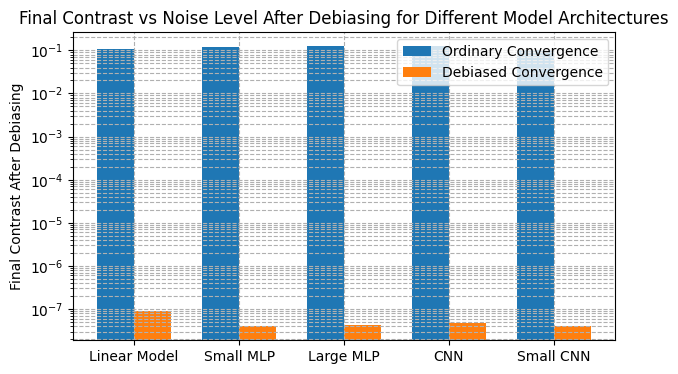

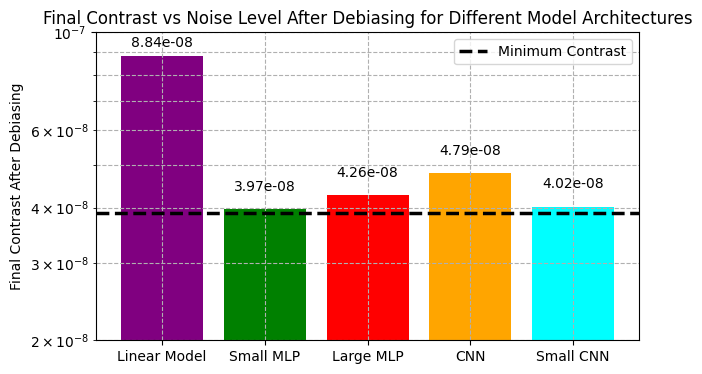

array([5.54065667e-08])

In [200]:
smr_conv = small_mlp_rand['convergence_stats']
lmr_conv = large_mlp_rand['convergence_stats']
lr_conv = linear_regular['convergence_stats']
cnn_conv = cnn_mlp['convergence_stats']
cnns_conv = cnn_mlp_small['convergence_stats']
min_contrast_attainable = 3.8837589430585855e-08

smr_conv_final_contrast_log_mean = np.array(smr_conv['final_contrast_log10']['mean'])
lmr_conv_final_contrast_log_mean = np.array(lmr_conv['final_contrast_log10']['mean'])
lr_conv_final_contrast_log_mean = np.array(lr_conv['final_contrast_log10']['mean'])
cnn_conv_final_contrast_log_mean = np.array(cnn_conv['final_contrast_log10']['mean'])
cnns_conv_final_contrast_log_mean = np.array(cnns_conv['final_contrast_log10']['mean'])

smr_conv_final_contrast = 10 ** smr_conv_final_contrast_log_mean
lmr_conv_final_contrast = 10 ** lmr_conv_final_contrast_log_mean
lr_conv_final_contrast = 10 ** lr_conv_final_contrast_log_mean
cnn_conv_final_contrast = 10 ** cnn_conv_final_contrast_log_mean
cnns_conv_final_contrast = 10 ** cnns_conv_final_contrast_log_mean

smr_pre_conv_final_contrast = smr_exp3_final_contrast[noise_level_index]
lmr_pre_conv_final_contrast = lmr_exp3_final_contrast[noise_level_index]
lr_pre_conv_final_contrast = lr_exp3_final_contrast[noise_level_index]
cnn_pre_conv_final_contrast = cnn_exp3_final_contrast[noise_level_index]
cnns_pre_conv_final_contrast = cnns_exp3_final_contrast[noise_level_index]


labels = ['Linear Model', 'Small MLP', 'Large MLP', 'CNN', 'Small CNN']
x = np.arange(len(labels))
width = 0.35

pre_conv_final_contrasts = [
        lr_pre_conv_final_contrast,
        smr_pre_conv_final_contrast,
        lmr_pre_conv_final_contrast,
        cnn_pre_conv_final_contrast,
        cnns_pre_conv_final_contrast
]

conv_final_contrasts = [
        lr_conv_final_contrast[0], 
        smr_conv_final_contrast[0], 
        lmr_conv_final_contrast[0], 
        cnn_conv_final_contrast[0], 
        cnns_conv_final_contrast[0]
]
plt.figure(figsize=(7, 3))

# plt.bar(x - width/2, pre_conv_final_contrasts, width, label='Ordinary Convergence')
# plt.bar(x + width/2, conv_final_contrasts, width, label='Unbiased Convergence')



plt.figure(figsize=(7,4))
# plt.bar(['Small MLP', 'Large MLP', 'Linear Model', 'CNN', "Small CNN"],)
# plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
# plt.xscale('log')

plt.bar(x - width/2, pre_conv_final_contrasts, width, label='Ordinary Convergence')
plt.bar(x + width/2, conv_final_contrasts, width, label='Debiased Convergence')
plt.xticks(x, labels)
plt.yscale('log')
plt.ylabel('Final Contrast After Debiasing')
plt.title('Final Contrast vs Noise Level After Debiasing for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

plt.figure(figsize=(7,4))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', 'CNN', "Small CNN"],
        [lr_conv_final_contrast[0], smr_conv_final_contrast[0], lmr_conv_final_contrast[0], cnn_conv_final_contrast[0], cnns_conv_final_contrast[0]],
        color=['purple', 'green', 'red', 'orange', 'cyan'])
# plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
# plt.xscale('log')
plt.axhline(y=min_contrast_attainable, color='black', linestyle='--', label='Minimum Contrast', linewidth=2.5)
plt.text(0, lr_conv_final_contrast[0]*1.05, f"{lr_conv_final_contrast[0]:.2e}", ha='center')
plt.text(1, smr_conv_final_contrast[0]*1.1, f"{smr_conv_final_contrast[0]:.2e}", ha='center')
plt.text(2, lmr_conv_final_contrast[0]*1.1, f"{lmr_conv_final_contrast[0]:.2e}", ha='center')
plt.text(3, cnn_conv_final_contrast[0]*1.1, f"{cnn_conv_final_contrast[0]:.2e}", ha='center')
plt.text(4, cnns_conv_final_contrast[0]*1.1, f"{cnns_conv_final_contrast[0]:.2e}", ha='center')

plt.yscale('log')
plt.ylabel('Final Contrast After Debiasing')
plt.title('Final Contrast vs Noise Level After Debiasing for Different Model Architectures')
plt.legend()
plt.ylim(2e-8, 1e-7)
plt.grid(True, which="both", ls="--")
plt.show()


smr_final_contrast

<Figure size 700x300 with 0 Axes>

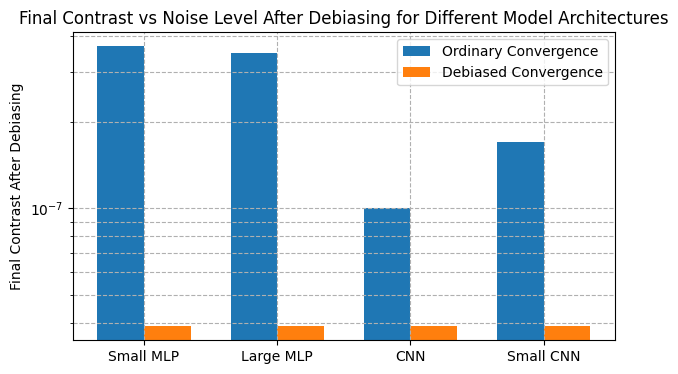

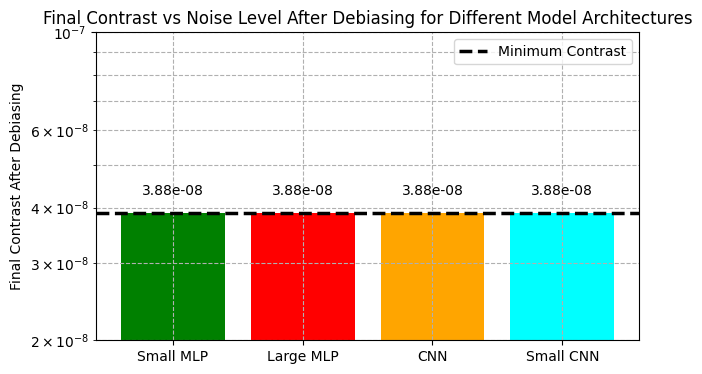

array([5.54065667e-08])

In [218]:
smr_conv = small_mlp_regular['convergence stats after iterations']
lmr_conv = large_mlp_regular['convergence stats after iterations']
lr_conv = linear_regular['convergence stats after iterations']
cnn_conv = cnn_mlp['convergence stats after iterations']
cnns_conv = cnn_mlp_small['convergence stats after iterations']
min_contrast_attainable = 3.8837589430585855e-08

smr_conv_final_contrast_log_mean = np.array(smr_conv['final_contrast_log10']['mean'])
lmr_conv_final_contrast_log_mean = np.array(lmr_conv['final_contrast_log10']['mean'])
lr_conv_final_contrast_log_mean = np.array(lr_conv['final_contrast_log10']['mean'])
cnn_conv_final_contrast_log_mean = np.array(cnn_conv['final_contrast_log10']['mean'])
cnns_conv_final_contrast_log_mean = np.array(cnns_conv['final_contrast_log10']['mean'])

smr_conv_final_contrast = 10 ** smr_conv_final_contrast_log_mean
lmr_conv_final_contrast = 10 ** lmr_conv_final_contrast_log_mean
lr_conv_final_contrast = 10 ** lr_conv_final_contrast_log_mean
cnn_conv_final_contrast = 10 ** cnn_conv_final_contrast_log_mean
cnns_conv_final_contrast = 10 ** cnns_conv_final_contrast_log_mean

smr_pre_conv_final_contrast = smr_exp3_final_contrast[noise_level_index]
lmr_pre_conv_final_contrast = lmr_exp3_final_contrast[noise_level_index]
lr_pre_conv_final_contrast = lr_exp3_final_contrast[noise_level_index]
cnn_pre_conv_final_contrast = cnn_exp3_final_contrast[noise_level_index]
cnns_pre_conv_final_contrast = cnns_exp3_final_contrast[noise_level_index]


labels = ['Small MLP', 'Large MLP', 'CNN', 'Small CNN']
x = np.arange(len(labels))
width = 0.35

pre_conv_final_contrasts = [
        # lr_pre_conv_final_contrast,
        smr_pre_conv_final_contrast,
        lmr_pre_conv_final_contrast,
        cnn_pre_conv_final_contrast,
        cnns_pre_conv_final_contrast
]

conv_final_contrasts = [
        # lr_conv_final_contrast[0], 
        smr_conv_final_contrast[0], 
        lmr_conv_final_contrast[0], 
        cnn_conv_final_contrast[0], 
        cnns_conv_final_contrast[0]
]
plt.figure(figsize=(7, 3))

# plt.bar(x - width/2, pre_conv_final_contrasts, width, label='Ordinary Convergence')
# plt.bar(x + width/2, conv_final_contrasts, width, label='Unbiased Convergence')



plt.figure(figsize=(7,4))
# plt.bar(['Small MLP', 'Large MLP', 'Linear Model', 'CNN', "Small CNN"],)
# plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
# plt.xscale('log')

plt.bar(x - width/2, pre_conv_final_contrasts, width, label='Ordinary Convergence')
plt.bar(x + width/2, conv_final_contrasts, width, label='Debiased Convergence')
plt.xticks(x, labels)
plt.yscale('log')
plt.ylabel('Final Contrast After Debiasing')
plt.title('Final Contrast vs Noise Level After Debiasing for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

plt.figure(figsize=(7,4))
plt.bar(['Small MLP', 'Large MLP', 'CNN', "Small CNN"],
        [smr_conv_final_contrast[0], lmr_conv_final_contrast[0], cnn_conv_final_contrast[0], cnns_conv_final_contrast[0]],
        color=['green', 'red', 'orange', 'cyan'])
# plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
# plt.xscale('log')
plt.axhline(y=min_contrast_attainable, color='black', linestyle='--', label='Minimum Contrast', linewidth=2.5)
# plt.text(0, lr_conv_final_contrast[0]*1.05, f"{lr_conv_final_contrast[0]:.2e}", ha='center')
plt.text(0, smr_conv_final_contrast[0]*1.1, f"{smr_conv_final_contrast[0]:.2e}", ha='center')
plt.text(1, lmr_conv_final_contrast[0]*1.1, f"{lmr_conv_final_contrast[0]:.2e}", ha='center')
plt.text(2, cnn_conv_final_contrast[0]*1.1, f"{cnn_conv_final_contrast[0]:.2e}", ha='center')
plt.text(3, cnns_conv_final_contrast[0]*1.1, f"{cnns_conv_final_contrast[0]:.2e}", ha='center')

plt.yscale('log')
plt.ylabel('Final Contrast After Debiasing')
plt.title('Final Contrast vs Noise Level After Debiasing for Different Model Architectures')
plt.legend()
plt.ylim(2e-8, 1e-7)
plt.grid(True, which="both", ls="--")
plt.show()


smr_final_contrast

### CNN Rand too

In [117]:
cnn_results_rand['cnn\\orth rand'].keys()

dict_keys(['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-do0.1', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-do0.1 small'])

In [222]:
cnn_mlp_rand = cnn_results_rand['cnn\\orth rand']
cnn_mlp_rand = cnn_mlp_rand['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images']
cnn_mlp_small_rand = cnn_results_rand['cnn\\orth rand']
cnn_mlp_small_rand = cnn_mlp_small_rand['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small']

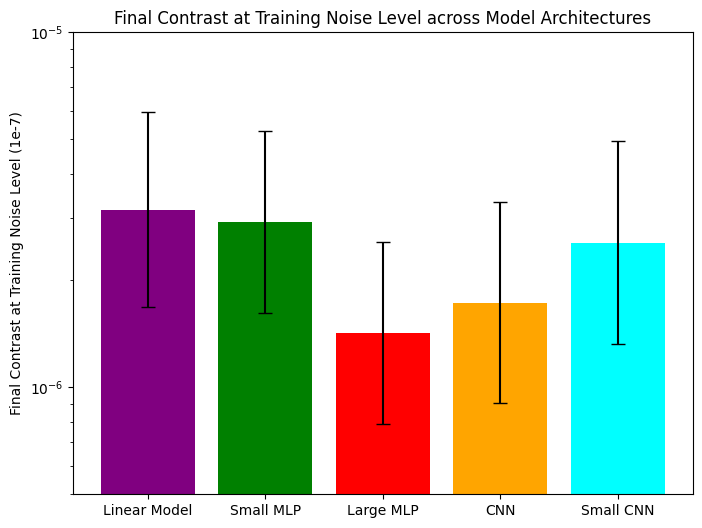

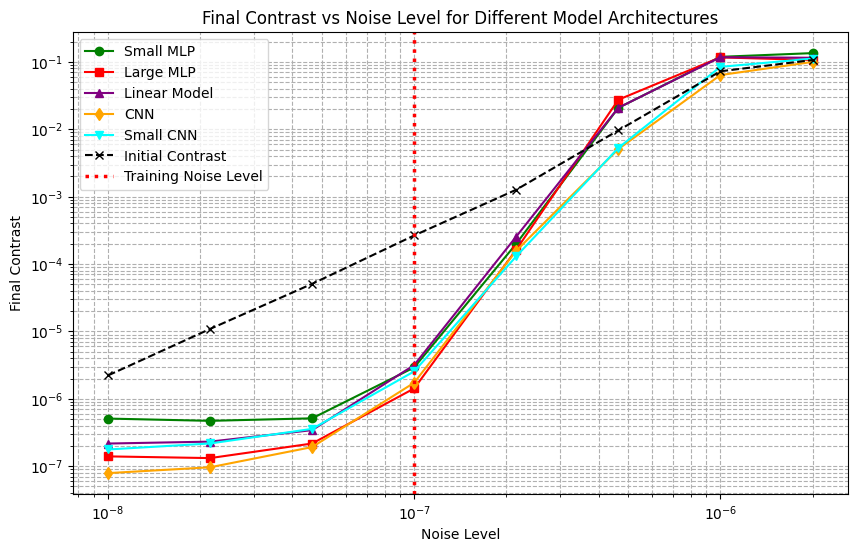

In [236]:
from matplotlib.patches import Circle


smr_exp1 = small_mlp_rand['exp1 evaluation stats']
lmr_exp1 = large_mlp_rand['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnn_exp1 = cnn_mlp_rand['exp1 evaluation stats']
cnns_exp1 = cnn_mlp_small_rand['exp1 evaluation stats']

smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
cnn_exp1_final_contrast_log_mean = np.array(cnn_exp1['final_contrast_log10']['mean'])
cnns_exp1_final_contrast_log_mean = np.array(cnns_exp1['final_contrast_log10']['mean'])

smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
cnn_exp1_final_contrast = 10 ** cnn_exp1_final_contrast_log_mean
cnns_exp1_final_contrast = 10 ** cnns_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
cnn_exp1_final_contrast_log_std = np.array(cnn_exp1['final_contrast_log10']['std'])
cnns_exp1_final_contrast_log_std = np.array(cnns_exp1['final_contrast_log10']['std'])

initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']

train_noise_level = 1e-7

noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]


def log_std_to_linear_error(log_mean, log_std):
    base = 10 ** log_mean
    lower_err = base - 10 ** (log_mean - log_std)
    upper_err = 10 ** (log_mean + log_std) - base
    return np.array([lower_err, upper_err])


model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_mean[noise_level_index], smr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_mean[noise_level_index], lmr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnn_exp1_final_contrast_log_mean[noise_level_index], cnn_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnns_exp1_final_contrast_log_mean[noise_level_index], cnns_exp1_final_contrast_log_std[noise_level_index])
]

yerr = np.array(model_error_bars).T

plt.figure(figsize=(8,6))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', 'CNN', "Small CNN"],
        [lr_exp1_final_contrast[noise_level_index], smr_exp1_final_contrast[noise_level_index], lmr_exp1_final_contrast[noise_level_index], cnn_exp1_final_contrast[noise_level_index], cnns_exp1_final_contrast[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'orange', 'cyan'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 1e-5)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnn_exp1_final_contrast, marker='d', label='CNN', color='orange')
plt.plot(noise_levels, cnns_exp1_final_contrast, marker='v', label='Small CNN', color='cyan')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
# plt.xlim(1e-8, 1.1e-7)
# plt.ylim(5e-8, 1e-5)

plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

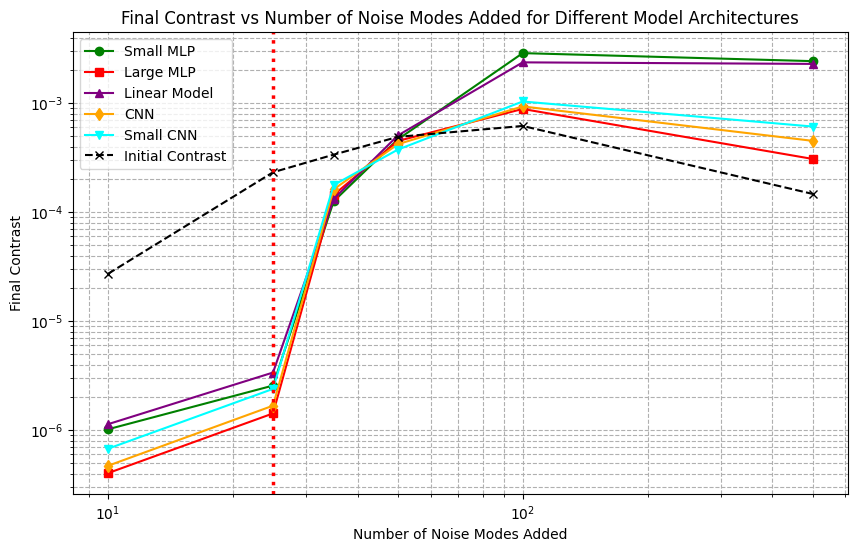

In [243]:
smr_exp2 = small_mlp_rand['exp2 evaluation stats']
lmr_exp2 = large_mlp_rand['exp2 evaluation stats']
lr_exp2 = linear_regular['exp2 evaluation stats']
cnn_exp2 = cnn_mlp_rand['exp2 evaluation stats']
cnns_exp2 = cnn_mlp_small_rand['exp2 evaluation stats']

noise_mode_amounts = smr_exp2['noise_mode_amounts']

smr_exp2_final_contrast_log_mean = np.array(smr_exp2['final_contrast_log10']['mean'])
lmr_exp2_final_contrast_log_mean = np.array(lmr_exp2['final_contrast_log10']['mean'])
lr_exp2_final_contrast_log_mean = np.array(lr_exp2['final_contrast_log10']['mean'])
cnn_exp2_final_contrast_log_mean = np.array(cnn_exp2['final_contrast_log10']['mean'])
cnns_exp2_final_contrast_log_mean = np.array(cnns_exp2['final_contrast_log10']['mean'])

smr_exp2_final_contrast = 10 ** smr_exp2_final_contrast_log_mean
lmr_exp2_final_contrast = 10 ** lmr_exp2_final_contrast_log_mean
lr_exp2_final_contrast = 10 ** lr_exp2_final_contrast_log_mean 
cnn_exp2_final_contrast = 10 ** cnn_exp2_final_contrast_log_mean
cnns_exp2_final_contrast = 10 ** cnns_exp2_final_contrast_log_mean

smr_exp2_cos_sim = np.array(smr_exp2['cosine_similarity']['mean'])
lmr_exp2_cos_sim = np.array(lmr_exp2['cosine_similarity']['mean'])
lr_exp2_cos_sim = np.array(lr_exp2['cosine_similarity']['mean'])
cnn_exp2_cos_sim = np.array(cnn_exp2['cosine_similarity']['mean'])
cnns_exp2_cos_sim = np.array(cnns_exp2['cosine_similarity']['mean'])

initial_contrast = 10 ** np.array(smr_exp2['initial_contrast_log10']['mean'])


plt.figure(figsize=(10,6))
plt.plot(noise_mode_amounts, smr_exp2_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_mode_amounts, lmr_exp2_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_mode_amounts, lr_exp2_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_mode_amounts, cnn_exp2_final_contrast, marker='d', label='CNN', color='orange')
plt.plot(noise_mode_amounts, cnns_exp2_final_contrast, marker='v', label='Small CNN', color='cyan')
plt.plot(noise_mode_amounts, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Number of Noise Modes Added')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Number of Noise Modes Added for Different Model Architectures')
plt.legend()
plt.axvline(x=25, color='red', linestyle=':', label='Training Noise Modes', linewidth=2.5)
plt.grid(True, which="both", ls="--")
plt.show()

In [237]:
print(noise_levels)

[1e-08, 2.1544346900318822e-08, 4.641588833612782e-08, 1e-07, 2.1544346900318822e-07, 4.6415888336127725e-07, 1e-06, 2e-06]


Debiasing did not quite work on the linear model, but on all the other models it looks like they reach a certain plateau, minimum possible for this simulation.

In [182]:
mlp_orth.keys()

dict_keys(['exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images'])

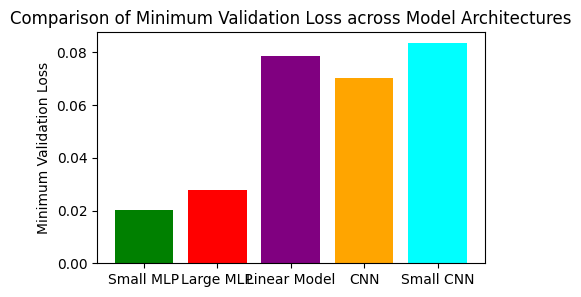

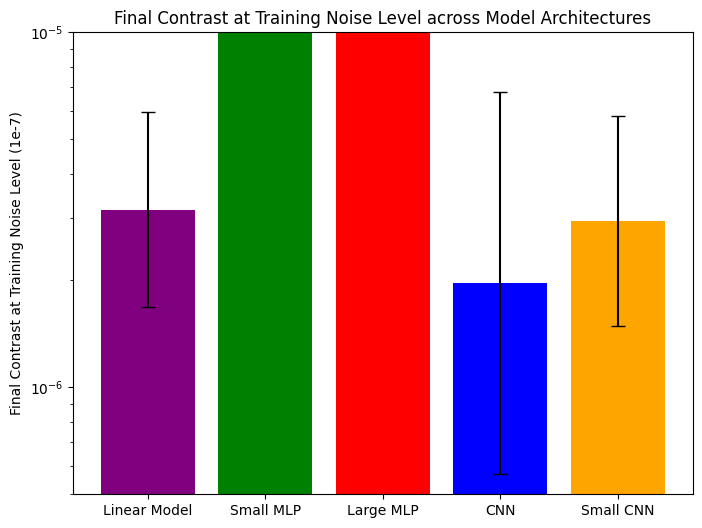

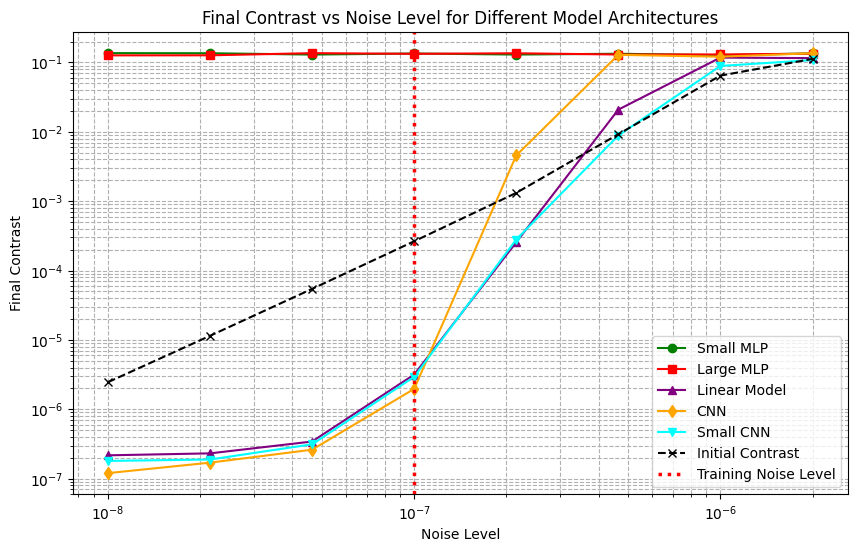

In [220]:
smr_split = mlp_orth['exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0']
lmr_split = mlp_orth['exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0']

plt.figure(figsize=(5,3))
plt.bar(['Small MLP', 'Large MLP', 'Linear Model', "CNN", "Small CNN"],
        [smr_split['min val loss'], lmr_split['min val loss'], linear_regular['min val loss'], cnn_mlp['min val loss'], cnn_mlp_small['min val loss']],
        color=['green', 'red', 'purple', 'orange', 'cyan'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss across Model Architectures')
plt.show()

smr_exp1 = smr_split['exp1 evaluation stats']
lmr_exp1 = lmr_split['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnn_exp1 = cnn_mlp['exp1 evaluation stats']
cnns_exp1 = cnn_mlp_small['exp1 evaluation stats']

smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
cnn_exp1_final_contrast_log_mean = np.array(cnn_exp1['final_contrast_log10']['mean'])
cnns_exp1_final_contrast_log_mean = np.array(cnns_exp1['final_contrast_log10']['mean'])

smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
cnn_exp1_final_contrast = 10 ** cnn_exp1_final_contrast_log_mean
cnns_exp1_final_contrast = 10 ** cnns_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
cnn_exp1_final_contrast_log_std = np.array(cnn_exp1['final_contrast_log10']['std'])
cnns_exp1_final_contrast_log_std = np.array(cnns_exp1['final_contrast_log10']['std'])
initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']
train_noise_level = 1e-7

noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]

model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_mean[noise_level_index], smr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_mean[noise_level_index], lmr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnn_exp1_final_contrast_log_mean[noise_level_index], cnn_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnns_exp1_final_contrast_log_mean[noise_level_index], cnns_exp1_final_contrast_log_std[noise_level_index]),
]
yerr = np.array(model_error_bars).T
plt.figure(figsize=(8,6))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', 'CNN', "Small CNN"],
        [lr_exp1_final_contrast[noise_level_index], smr_exp1_final_contrast[noise_level_index], lmr_exp1_final_contrast[noise_level_index], cnn_exp1_final_contrast[noise_level_index], cnns_exp1_final_contrast[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'blue', 'orange'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 1e-5)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnn_exp1_final_contrast, marker='d', label='CNN', color='orange')
plt.plot(noise_levels, cnns_exp1_final_contrast, marker='v', label='Small CNN', color='cyan')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

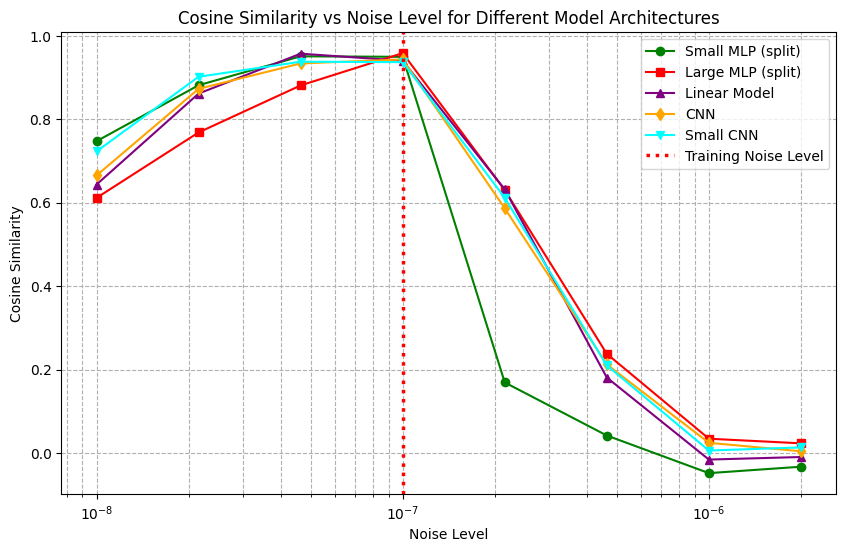

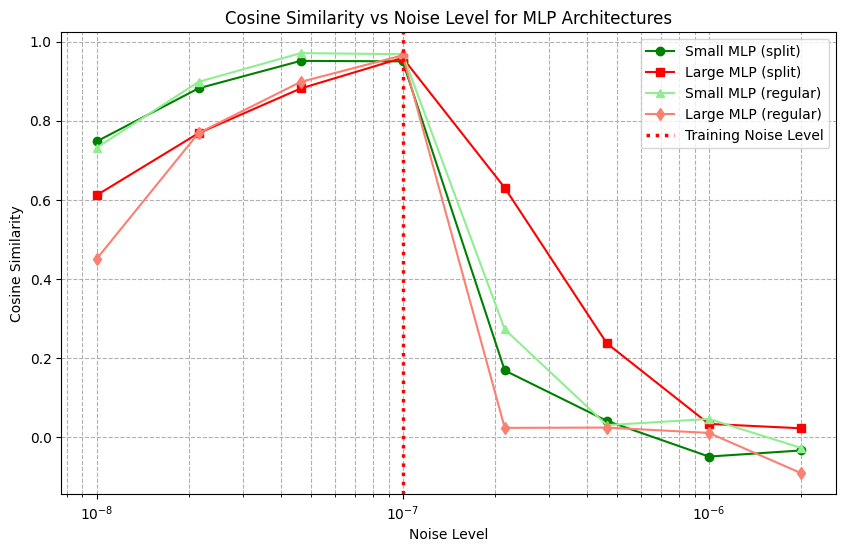

In [221]:
smr_split_cos_sim = np.array(smr_exp1['cosine_similarity']['mean'])
lmr_split_cos_sim = np.array(lmr_exp1['cosine_similarity']['mean'])
lr_exp1_cos_sim = np.array(lr_exp1['cosine_similarity']['mean'])
cnn_exp1_cos_sim = np.array(cnn_exp1['cosine_similarity']['mean'])
cnns_exp1_cos_sim = np.array(cnns_exp1['cosine_similarity']['mean'])

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_split_cos_sim, marker='o', label='Small MLP (split)', color='green')
plt.plot(noise_levels, lmr_split_cos_sim, marker='s', label='Large MLP (split)', color='red')
plt.plot(noise_levels, lr_exp1_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnn_exp1_cos_sim, marker='d', label='CNN', color='orange')
plt.plot(noise_levels, cnns_exp1_cos_sim, marker='v', label='Small CNN', color='cyan')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_split_cos_sim, marker='o', label='Small MLP (split)', color='green')
plt.plot(noise_levels, lmr_split_cos_sim, marker='s', label='Large MLP (split)', color='red')
plt.plot(noise_levels, smr_exp1_cos_sim, marker='^', label='Small MLP (regular)', color='lightgreen')
plt.plot(noise_levels, lmr_exp1_cos_sim, marker='d', label='Large MLP (regular)', color='salmon')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for MLP Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Optimizing for COS similarity directly doesn't seem to be too good of an idea.

In [151]:
cnn_results_rand['cnn\\orth rand'].keys()

dict_keys(['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-do0.1', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-do0.1 small'])

In [185]:
mlp_orth_rand.keys()

dict_keys(['exp-fc1-log-ep1500-bs256-lr1e-3-s42-h256-128-64-images', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-mc0-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h256-128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h256-128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.1'])

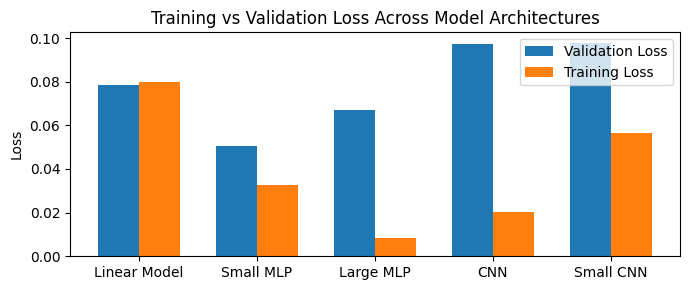

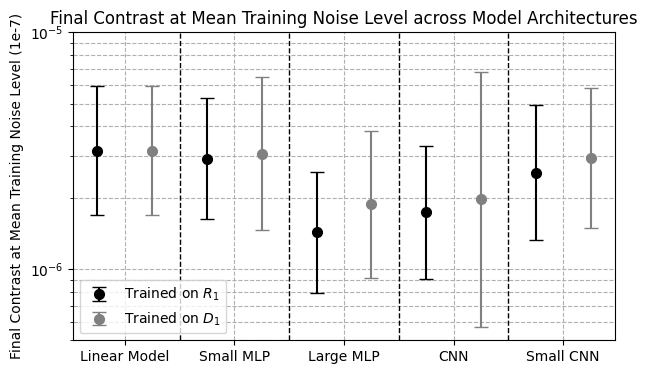

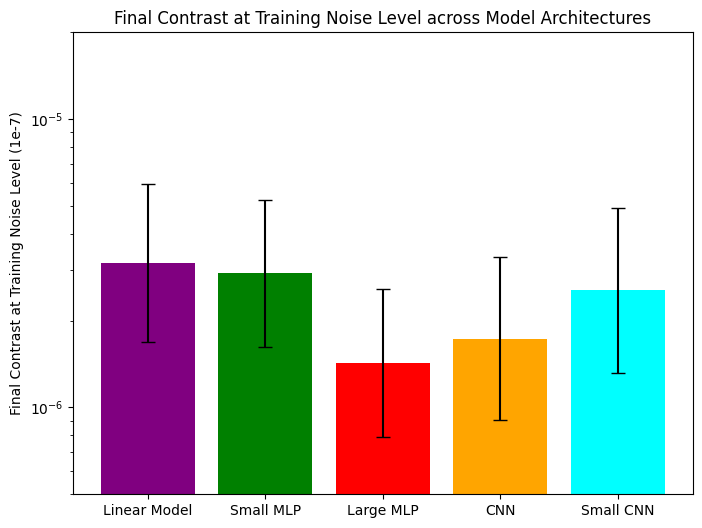

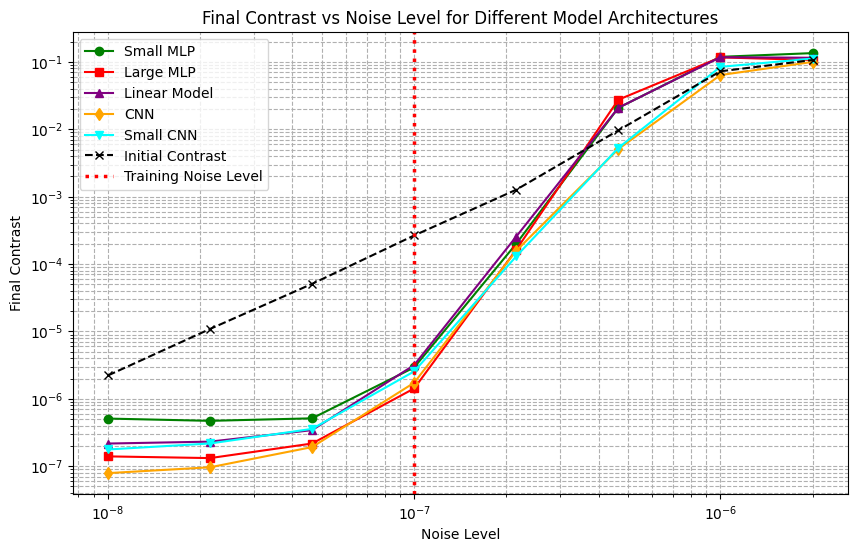

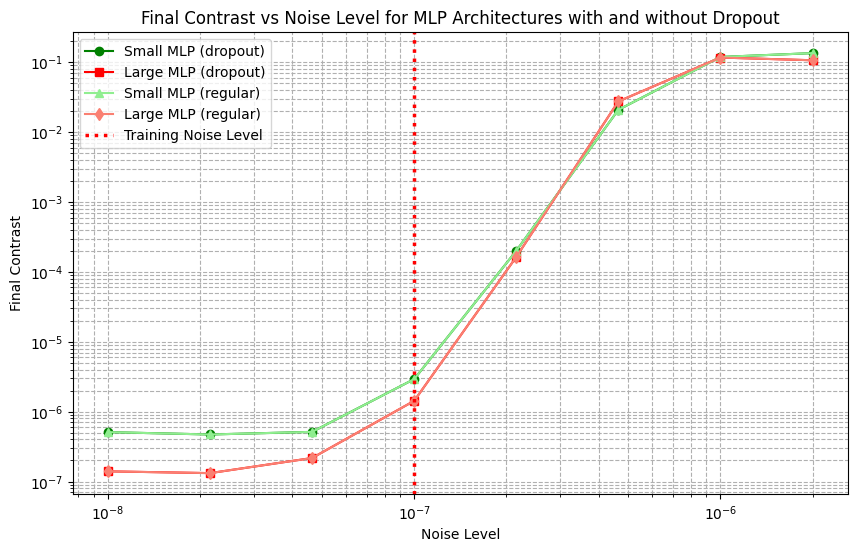

In [173]:
smr_rand_drop = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1']
lmr_rand_drop = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.1']
smr_rand = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images']
lmr_rand = mlp_orth_rand['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images']
cnn_mlp_rand = cnn_results_rand['cnn\\orth rand']['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images']
cnn_mlp_small_rand = cnn_results_rand['cnn\\orth rand']['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small']

labels = ['Linear Model', 'Small MLP', 'Large MLP', 'CNN', 'Small CNN']
x = np.arange(len(labels))
width = 0.35

val_losses = [
    linear_regular['min val loss'],
    smr_rand['min val loss'],
    lmr_rand['min val loss'],
    cnn_mlp_rand['min val loss'],
    cnn_mlp_small_rand['min val loss']
]

train_losses = [
    linear_regular[' train loss'],
    smr_rand[' train loss'],
    lmr_rand[' train loss'],
    cnn_mlp_rand[' train loss'],
    cnn_mlp_small_rand[' train loss']
]

plt.figure(figsize=(7, 3))

plt.bar(x - width/2, val_losses, width, label='Validation Loss')
plt.bar(x + width/2, train_losses, width, label='Training Loss')

plt.xticks(x, labels)
plt.ylabel('Loss')
plt.title('Training vs Validation Loss Across Model Architectures')
plt.legend()
plt.tight_layout()
plt.show()





smr_exp1 = smr_rand['exp1 evaluation stats']
lmr_exp1 = lmr_rand['exp1 evaluation stats']
lr_exp1 = linear_regular['exp1 evaluation stats']
cnn_exp1 = cnn_mlp_rand['exp1 evaluation stats']
cnns_exp1 = cnn_mlp_small_rand['exp1 evaluation stats']

smr_exp1_normal = 

smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
cnn_exp1_final_contrast_log_mean = np.array(cnn_exp1['final_contrast_log10']['mean'])
cnns_exp1_final_contrast_log_mean = np.array(cnns_exp1['final_contrast_log10']['mean'])

smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
cnn_exp1_final_contrast = 10 ** cnn_exp1_final_contrast_log_mean
cnns_exp1_final_contrast = 10 ** cnns_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
cnn_exp1_final_contrast_log_std = np.array(cnn_exp1['final_contrast_log10']['std'])
cnns_exp1_final_contrast_log_std = np.array(cnns_exp1['final_contrast_log10']['std'])

initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])

noise_levels = smr_exp1['noise_levels']
train_noise_level = 1e-7
noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]

model_error_bars = [
    log_std_to_linear_error(lr_exp1_final_contrast_log_mean[noise_level_index], lr_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(smr_exp1_final_contrast_log_drop_mean[noise_level_index], smr_exp1_final_contrast_log_std_drop[noise_level_index]),
    log_std_to_linear_error(lmr_exp1_final_contrast_log_drop_mean[noise_level_index], lmr_exp1_final_contrast_log_std_drop[noise_level_index]),
    log_std_to_linear_error(cnn_exp1_final_contrast_log_mean[noise_level_index], cnn_exp1_final_contrast_log_std[noise_level_index]),
    log_std_to_linear_error(cnns_exp1_final_contrast_log_mean[noise_level_index], cnns_exp1_final_contrast_log_std[noise_level_index]),
]

yerr = np.array(model_error_bars).T


means2 = [
    lr_exp1_final_contrast[noise_level_index],
    smr_exp1_final_contrast[noise_level_index],
    lmr_exp1_final_contrast[noise_level_index],
    cnn_exp1_final_contrast[noise_level_index],
    cnns_exp1_final_contrast[noise_level_index],
]

labels = ['Linear Model', 'Small MLP', 'Large MLP', 'CNN', 'Small CNN']
x = np.arange(len(labels))

plt.figure(figsize=(7, 4))

plt.errorbar(
    x - 0.25,
    means2,
    yerr=yerr,
    fmt='o',
    markersize=7,
    capsize=5,
    linestyle='none',
    color='black',
        label='Trained on $R_1$'
)

plt.errorbar(
    x + 0.25,
    means,
    yerr=yerr_original,
    fmt='o',
    markersize=7,
    capsize=5,
    linestyle='none',
    color='gray',
    label='Trained on $D_1$'
)

plt.axvline(x=0.5, color='black', linestyle='--', linewidth=1)
plt.axvline(x=1.5, color='black', linestyle='--', linewidth=1)
plt.axvline(x=2.5, color='black', linestyle='--', linewidth=1)
plt.axvline(x=3.5, color='black', linestyle='--', linewidth=1)

plt.xticks(x, labels)
plt.ylabel('Final Contrast at Mean Training Noise Level (1e-7)')
plt.title('Final Contrast at Mean Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 1e-5)
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


plt.figure(figsize=(8,6))
plt.bar(['Linear Model', 'Small MLP', 'Large MLP', 'CNN', 'Small CNN'],
        [lr_exp1_final_contrast[noise_level_index], smr_exp1_final_contrast_drop[noise_level_index], lmr_exp1_final_contrast_drop[noise_level_index], cnn_exp1_final_contrast[noise_level_index], cnns_exp1_final_contrast[noise_level_index]],
        yerr=yerr,
        color=['purple', 'green', 'red', 'orange', 'cyan'], capsize=5)
plt.ylabel('Final Contrast at Training Noise Level (1e-7)')
plt.title('Final Contrast at Training Noise Level across Model Architectures')
plt.yscale('log')
plt.ylim(5e-7, 2e-5)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast_drop, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast_drop, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnn_exp1_final_contrast, marker='d', label='CNN', color='orange')
plt.plot(noise_levels, cnns_exp1_final_contrast, marker='v', label='Small CNN', color='cyan')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
# plt.xlim(0.8e-7, 5e-7)

plt.show()

plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast_drop, marker='o', label='Small MLP (dropout)', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast_drop, marker='s', label='Large MLP (dropout)', color='red')
plt.plot(noise_levels, smr_exp1_final_contrast, marker='^', label='Small MLP (regular)', color='lightgreen')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='d', label='Large MLP (regular)', color='salmon')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for MLP Architectures with and without Dropout')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


In [184]:
cnn_LA.keys()

dict_keys(['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-small', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-wd0.0005-do0.1', 'exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-wd0.0005-do0.1 small'])

In [244]:
mlp_LA = results['mlp\\LA']
linear_LA = results['linear\\LA']
cnn_LA_experiments = cnn_results2['cnn\\LA new']

In [251]:
linear_LA.keys()

dict_keys(['exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images'])

In [253]:
mlp_LA.keys()

dict_keys(['exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h128-64-images-mc0-do0.1', 'exp-fc1-zscore-ep1250-bs256-lr1e-3-s42-h512-256-128-images-wd0.0005-mc0', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images-do0.1', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.2', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-wd0.0005'])

In [260]:
mlp_results_LA_clean_sub.keys()

dict_keys(['exp-fc1-zscore-ep1500-bs2048-lr1e-3-s42-h512-256-128-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images'])

In [ ]:
mlp_results_LA_clean_sub = mlp_results_LA_clean['mlp\\LA clean']
mlp_results_LA_clean_sub.keys()

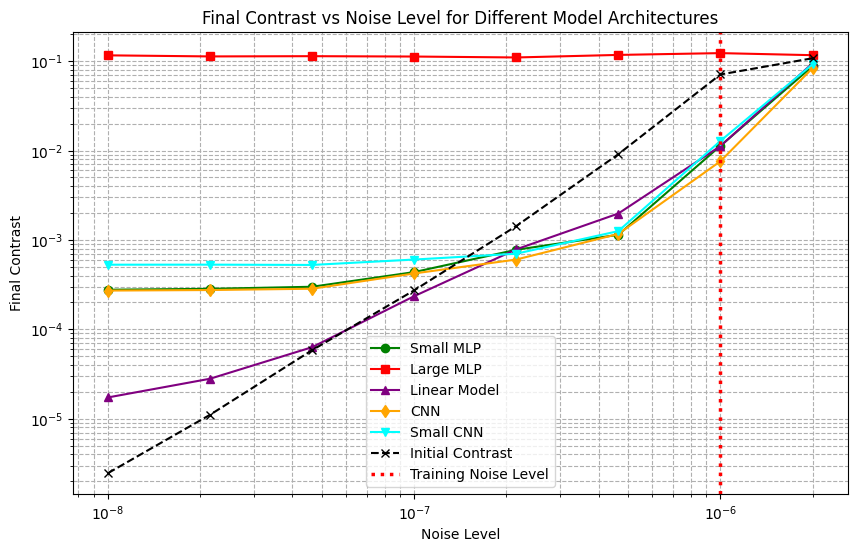

In [264]:
cnn_LA = cnn_LA_experiments['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images']
cnns_LA = cnn_LA_experiments['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-small']
large_mlp_LA = mlp_results_LA_clean_sub['exp-fc1-zscore-ep1500-bs2048-lr1e-3-s42-h512-256-128-images']
small_mlp_LA = mlp_LA['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images']
lm_LA = linear_LA['exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images']

smr_exp1 = small_mlp_LA['exp1 evaluation stats']
lmr_exp1 = large_mlp_LA['exp1 evaluation stats']
lr_exp1 = lm_LA['exp1 evaluation stats']
cnn_exp1 = cnn_LA['exp1 evaluation stats']
cnns_exp1 = cnns_LA['exp1 evaluation stats']

smr_exp1_final_contrast_log_mean = np.array(smr_exp1['final_contrast_log10']['mean'])
lmr_exp1_final_contrast_log_mean = np.array(lmr_exp1['final_contrast_log10']['mean'])
lr_exp1_final_contrast_log_mean = np.array(lr_exp1['final_contrast_log10']['mean'])
cnn_exp1_final_contrast_log_mean = np.array(cnn_exp1['final_contrast_log10']['mean'])
cnns_exp1_final_contrast_log_mean = np.array(cnns_exp1['final_contrast_log10']['mean'])

smr_exp1_final_contrast = 10 ** smr_exp1_final_contrast_log_mean
lmr_exp1_final_contrast = 10 ** lmr_exp1_final_contrast_log_mean
lr_exp1_final_contrast = 10 ** lr_exp1_final_contrast_log_mean
cnn_exp1_final_contrast = 10 ** cnn_exp1_final_contrast_log_mean
cnns_exp1_final_contrast = 10 ** cnns_exp1_final_contrast_log_mean

smr_exp1_final_contrast_log_std = np.array(smr_exp1['final_contrast_log10']['std'])
lmr_exp1_final_contrast_log_std = np.array(lmr_exp1['final_contrast_log10']['std'])
lr_exp1_final_contrast_log_std = np.array(lr_exp1['final_contrast_log10']['std'])
cnn_exp1_final_contrast_log_std = np.array(cnn_exp1['final_contrast_log10']['std'])
cnns_exp1_final_contrast_log_std = np.array(cnns_exp1['final_contrast_log10']['std'])

initial_contrast = 10 ** np.array(smr_exp1['initial_contrast_log10']['mean'])
noise_levels = smr_exp1['noise_levels']
train_noise_level = 1e-6
noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]


plt.figure(figsize=(10,6))
plt.plot(noise_levels, smr_exp1_final_contrast, marker='o', label='Small MLP', color='green')
plt.plot(noise_levels, lmr_exp1_final_contrast, marker='s', label='Large MLP', color='red')
plt.plot(noise_levels, lr_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnn_exp1_final_contrast, marker='d', label='CNN', color='orange')
plt.plot(noise_levels, cnns_exp1_final_contrast, marker='v', label='Small CNN', color='cyan')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures')
plt.legend()
plt.grid(True, which="both", ls="--")
# plt.xlim(0.8e-7, 5e-7)

plt.show()

In [258]:
mlp_results_LA_clean_sub = mlp_results_LA_clean['mlp\\LA clean']
mlp_results_LA_clean_sub.keys()

dict_keys(['exp-fc1-zscore-ep1500-bs2048-lr1e-3-s42-h512-256-128-images', 'exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images'])

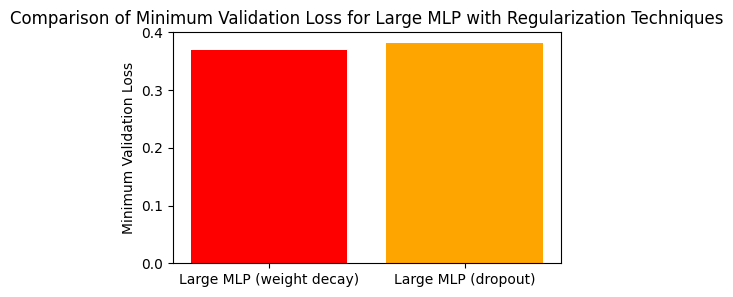

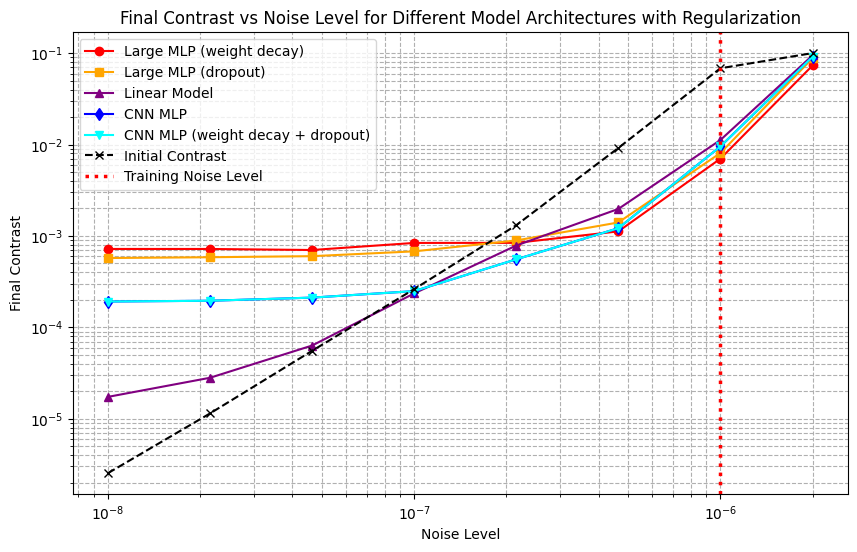

In [ ]:
large_mlp_LA_wd = mlp_LA['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-wd0.0005']
large_mlp_LA_drop = mlp_LA['exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images-do0.2']
lm_LA = linear_LA['exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images']
cnn_LA = cnn_LA_experiments['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images']
cnns_LA= cnn_LA_experiments['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-small']
cnn_LA_wd_drop = cnn_LA_experiments['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-wd0.0005-do0.1']
cnns_LA_wd_drop = cnn_LA_experiments['exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images-wd0.0005-do0.1 small']

plt.figure(figsize=(5,3))
plt.bar(['Large MLP (weight decay)', 'Large MLP (dropout)'],
        [large_mlp_LA_wd['min val loss'], large_mlp_LA_drop['min val loss']],
        color=['red', 'orange'])
plt.ylabel('Minimum Validation Loss')
plt.title('Comparison of Minimum Validation Loss for Large MLP with Regularization Techniques')
plt.show()

large_mlp_LA_wd_exp1 = large_mlp_LA_wd['exp1 evaluation stats']
large_mlp_LA_drop_exp1 = large_mlp_LA_drop['exp1 evaluation stats']
lm_LA_exp1 = lm_LA['exp1 evaluation stats']
cnn_LA_exp1 = cnn_LA['exp1 evaluation stats']
cnn_LA_wd_drop_exp1 = cnn_LA_wd_drop['exp1 evaluation stats']
cnns_LA_wd_drop_exp1 = cnns_LA_wd_drop['exp1 evaluation stats']
cnns_LA_exp1 = cnns_LA['exp1 evaluation stats']

large_mlp_LA_wd_exp1_final_contrast_log_mean = np.array(large_mlp_LA_wd_exp1['final_contrast_log10']['mean'])
large_mlp_LA_drop_exp1_final_contrast_log_mean = np.array(large_mlp_LA_drop_exp1['final_contrast_log10']['mean'])
lm_LA_exp1_final_contrast_log_mean = np.array(lm_LA_exp1['final_contrast_log10']['mean'])
cnn_LA_exp1_final_contrast_log_mean = np.array(cnn_LA_exp1['final_contrast_log10']['mean'])
cnns_LA_wd_drop_exp1_final_contrast_log_mean = np.array(cnns_LA_wd_drop_exp1['final_contrast_log10']['mean'])
large_mlp_LA_wd_exp1_final_contrast = 10 ** large_mlp_LA_wd_exp1_final_contrast_log_mean
large_mlp_LA_drop_exp1_final_contrast = 10 ** large_mlp_LA_drop_exp1_final_contrast_log_mean
lm_LA_exp1_final_contrast = 10 ** lm_LA_exp1_final_contrast_log_mean
cnns_LA_exp1_final_contrast = 10 ** cnns_LA_wd_drop_exp1_final_contrast_log_mean
cnns_LA_wd_drop_exp1_final_contrast = 10 ** cnns_LA_wd_drop_exp1_final_contrast_log_mean
initial_contrast = 10 ** np.array(large_mlp_LA_wd_exp1['initial_contrast_log10']['mean'])

noise_levels = large_mlp_LA_wd_exp1['noise_levels']
train_noise_level = 1e-6
noise_level_index = np.where(np.isclose(noise_levels, train_noise_level))[0][0]

plt.figure(figsize=(10,6))
plt.plot(noise_levels, large_mlp_LA_wd_exp1_final_contrast, marker='o', label='Large MLP (weight decay)', color='red')
plt.plot(noise_levels, large_mlp_LA_drop_exp1_final_contrast, marker='s', label='Large MLP (dropout)', color='orange')
plt.plot(noise_levels, lm_LA_exp1_final_contrast, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnns_LA_wd_drop_exp1_final_contrast, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, cnns_LA_wd_drop_exp1_final_contrast, marker='v', label='CNN MLP (weight decay + dropout)', color='cyan')
plt.plot(noise_levels, initial_contrast, marker='x', label='Initial Contrast', color='black', linestyle='--')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level for Different Model Architectures with Regularization')
plt.legend()
# plt.xlim(1e-7, 2e-6)
# plt.ylim(1e-4, 1e-1)
plt.grid(True, which="both", ls="--")
plt.show()


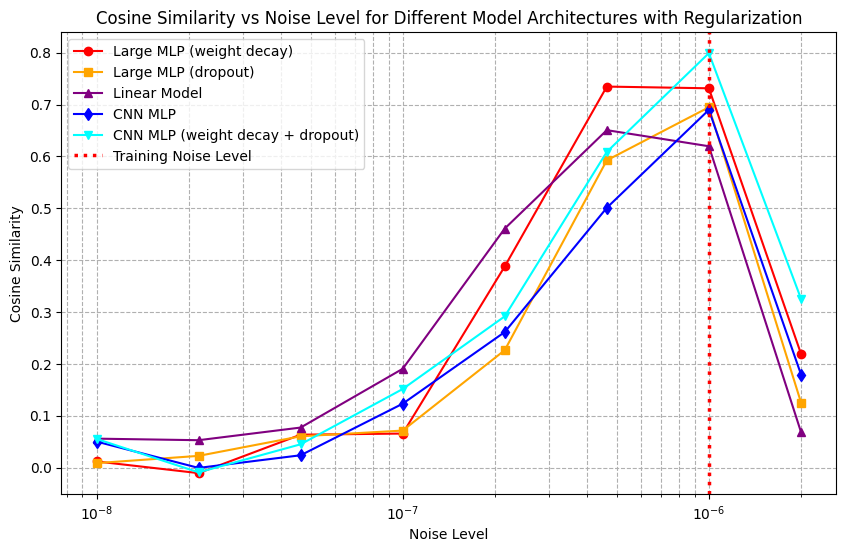

In [205]:
large_mlp_LA_wd_exp1_cos_sim = np.array(large_mlp_LA_wd_exp1['cosine_similarity']['mean'])
large_mlp_LA_drop_exp1_cos_sim = np.array(large_mlp_LA_drop_exp1['cosine_similarity']['mean'])
lm_LA_exp1_cos_sim = np.array(lm_LA_exp1['cosine_similarity']['mean'])
cnnr_LA_exp1_cos_sim = np.array(cnnr_LA_exp1['cosine_similarity']['mean'])
cnnr_LA_wd_drop_exp1_cos_sim = np.array(cnnr_LA_wd_drop_exp1['cosine_similarity']['mean'])

plt.figure(figsize=(10,6))
plt.plot(noise_levels, large_mlp_LA_wd_exp1_cos_sim, marker='o', label='Large MLP (weight decay)', color='red')
plt.plot(noise_levels, large_mlp_LA_drop_exp1_cos_sim, marker='s', label='Large MLP (dropout)', color='orange')
plt.plot(noise_levels, lm_LA_exp1_cos_sim, marker='^', label='Linear Model', color='purple')
plt.plot(noise_levels, cnnr_LA_exp1_cos_sim, marker='d', label='CNN MLP', color='blue')
plt.plot(noise_levels, cnnr_LA_wd_drop_exp1_cos_sim, marker='v', label='CNN MLP (weight decay + dropout)', color='cyan')
plt.axvline(x=train_noise_level, color='red', linestyle=':', label='Training Noise Level', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Noise Level for Different Model Architectures with Regularization')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()